# Task 1. EDA   
**Author:** Alexey Shumilov  

Time period of used data: **2025-12-01 – 2025-12-02**.

---


## Imports

In [ ]:
import pandas as pd
import numpy as np
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Монтируем диск
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Downloading data

In [ ]:
# Путь к данным (измените под свою структуру)
BASE_PATH = 'drive/MyDrive/liquidation_task/data/'   # для Colab
# BASE_PATH = './data/'                              # для локального запуска

SYMBOLS = ['btcusdt', 'ethusdt']
START_DATE = dt.datetime(2025, 12, 1, 0, 0, 0)
END_DATE   = dt.datetime(2025, 12, 2, 0, 0, 0)

START_TS = int(START_DATE.timestamp() * 1_000_000)
END_TS   = int(END_DATE.timestamp() * 1_000_000)

def load_filtered_parquet(file_path, start_ts, end_ts):
    """Загружает Parquet с фильтром по timestamp (микросекунды)."""
    filters = [('timestamp', '>=', start_ts), ('timestamp', '<=', end_ts)]
    try:
        df = pd.read_parquet(file_path, filters=filters)
        print(f"✓ Загружено {len(df):,} строк из {file_path}")
        return df
    except Exception as e:
        print(f"✗ Ошибка загрузки {file_path}: {e}")
        return pd.DataFrame()

# Словарь для хранения данных
data = {
    'binance_trades': {},
    'binance_bbo': {},
    'binance_liquidations': {},
    'bybit_liquidations': {}
}

for sym in SYMBOLS:
    data['binance_trades'][sym] = load_filtered_parquet(
        BASE_PATH + f'binance_trades/perp_{sym}.parquet', START_TS, END_TS
    )
    data['binance_bbo'][sym] = load_filtered_parquet(
        BASE_PATH + f'binance_booktickers/perp_{sym}.parquet', START_TS, END_TS
    )
    data['binance_liquidations'][sym] = load_filtered_parquet(
        BASE_PATH + f'binance_liquidations/perp_{sym}.parquet', START_TS, END_TS
    )
    data['bybit_liquidations'][sym] = load_filtered_parquet(
        BASE_PATH + f'bybit_liquidations/{sym}.parquet', START_TS, END_TS
    )

# Добавляем человеко-читаемую колонку datetime
for key in data:
    for sym in SYMBOLS:
        df = data[key][sym]
        if not df.empty:
            df['datetime'] = pd.to_datetime(df['timestamp'], unit='us')
            df.sort_values('timestamp', inplace=True)
            df.reset_index(drop=True, inplace=True)

✓ Загружено 6,767,867 строк из drive/MyDrive/liquidation_task/data/binance_trades/perp_btcusdt.parquet
✓ Загружено 1,322,826 строк из drive/MyDrive/liquidation_task/data/binance_booktickers/perp_btcusdt.parquet
✓ Загружено 2,922 строк из drive/MyDrive/liquidation_task/data/binance_liquidations/perp_btcusdt.parquet
✓ Загружено 7,042 строк из drive/MyDrive/liquidation_task/data/bybit_liquidations/btcusdt.parquet
✓ Загружено 10,475,188 строк из drive/MyDrive/liquidation_task/data/binance_trades/perp_ethusdt.parquet
✓ Загружено 1,453,969 строк из drive/MyDrive/liquidation_task/data/binance_booktickers/perp_ethusdt.parquet
✓ Загружено 2,699 строк из drive/MyDrive/liquidation_task/data/binance_liquidations/perp_ethusdt.parquet
✓ Загружено 4,696 строк из drive/MyDrive/liquidation_task/data/bybit_liquidations/ethusdt.parquet


## Task 1.1 – Foundational EDA

### Data Quality Check

In [ ]:
print("=== Проверка пропусков и дубликатов ===\n")
for key, sym_dict in data.items():
    for sym, df in sym_dict.items():
        if df.isnull().any().any():
            print(f"⚠️ Пропуски найдены: {key} - {sym}")
        else:
            print(f"✓ Пропусков нет: {key} - {sym}")

        dup = df.duplicated().sum()
        if dup:
            print(f"  → Удалено дубликатов: {dup} ({dup/len(df):.2%})")
            df.drop_duplicates(inplace=True)
        else:
            print(f"  → Дубликатов нет")

=== Проверка пропусков и дубликатов ===

✓ Пропусков нет: binance_trades - btcusdt
  → Удалено дубликатов: 1216038 (17.97%)
✓ Пропусков нет: binance_trades - ethusdt
  → Удалено дубликатов: 1558156 (14.87%)
✓ Пропусков нет: binance_bbo - btcusdt
  → Дубликатов нет
✓ Пропусков нет: binance_bbo - ethusdt
  → Дубликатов нет
✓ Пропусков нет: binance_liquidations - btcusdt
  → Дубликатов нет
✓ Пропусков нет: binance_liquidations - ethusdt
  → Дубликатов нет
✓ Пропусков нет: bybit_liquidations - btcusdt
  → Дубликатов нет
✓ Пропусков нет: bybit_liquidations - ethusdt
  → Дубликатов нет


### Univariate Analysis

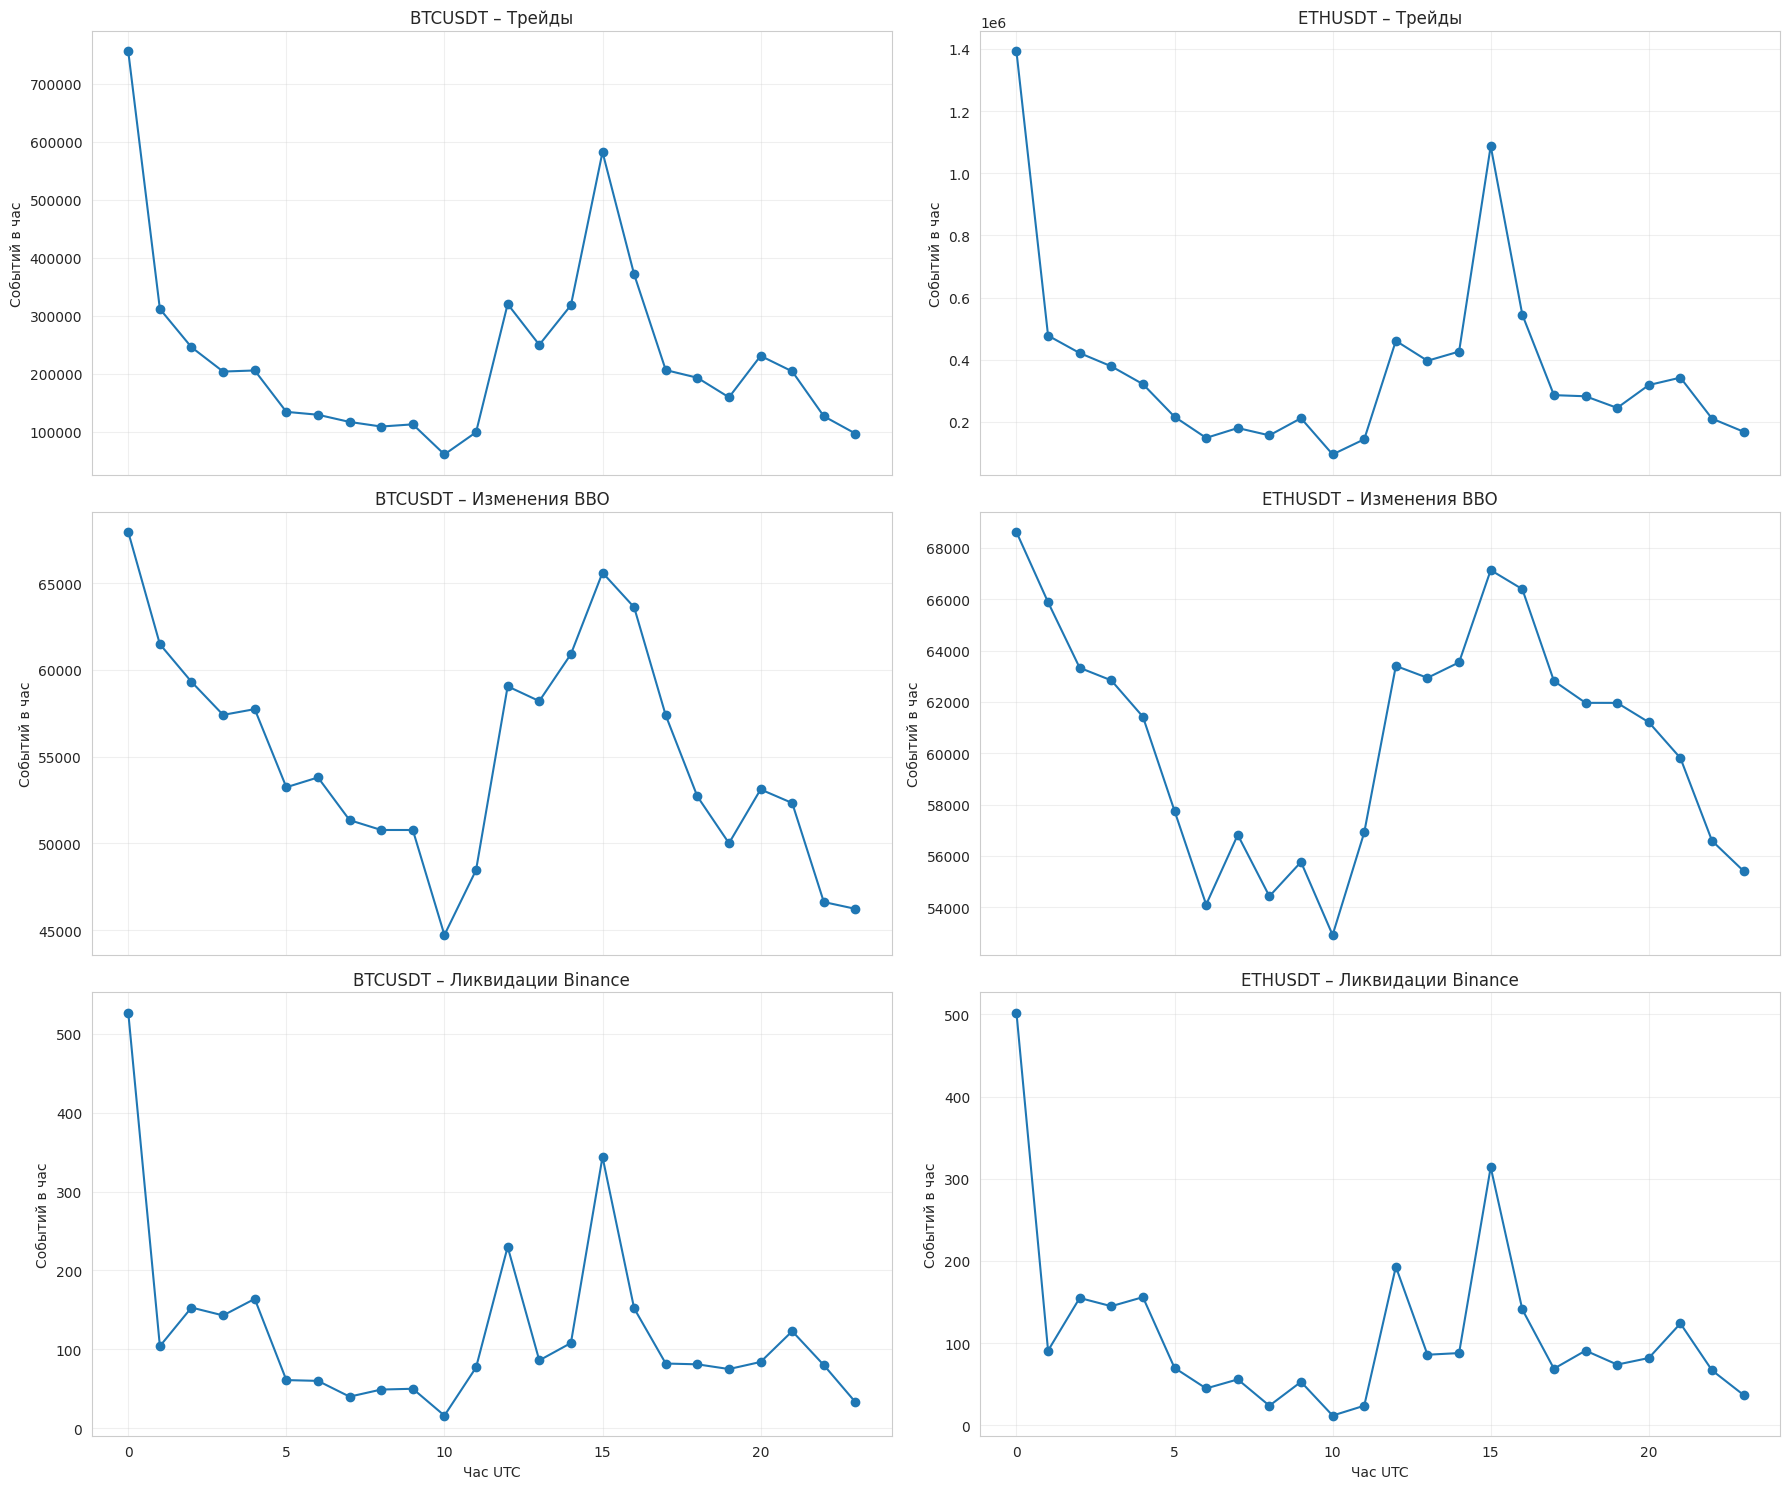


=== Общие статистики ===

BTCUSDT:
  Трейдов: 5,551,829
  BBO-событий: 1,322,826
  Ликвидаций Binance: 2,922
  Ликвидаций Bybit: 7,042

ETHUSDT:
  Трейдов: 8,917,032
  BBO-событий: 1,453,969
  Ликвидаций Binance: 2,699
  Ликвидаций Bybit: 4,696


In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(18, 15), sharex=True)
row_titles = ['Трейды', 'Изменения BBO', 'Ликвидации Binance']
data_keys = ['binance_trades', 'binance_bbo', 'binance_liquidations']

for row_idx, key in enumerate(data_keys):
    for col_idx, sym in enumerate(SYMBOLS):
        ax = axes[row_idx, col_idx]
        df = data[key][sym]
        if not df.empty:
            hour_counts = df['datetime'].dt.hour.value_counts().sort_index()
            hour_counts = hour_counts.reindex(range(24), fill_value=0)
            ax.plot(hour_counts.index, hour_counts.values, marker='o', linestyle='-')
            ax.set_title(f'{sym.upper()} – {row_titles[row_idx]}')
            ax.set_ylabel('Событий в час')
            ax.grid(True, alpha=0.3)
        else:
            ax.set_title(f'{sym.upper()} – нет данных')
        if row_idx == 2:
            ax.set_xlabel('Час UTC')
plt.tight_layout()
plt.show()

# Общие количества
print("\n=== Общие статистики ===")
for sym in SYMBOLS:
    print(f"\n{sym.upper()}:")
    print(f"  Трейдов: {len(data['binance_trades'][sym]):,}")
    print(f"  BBO-событий: {len(data['binance_bbo'][sym]):,}")
    print(f"  Ликвидаций Binance: {len(data['binance_liquidations'][sym]):,}")
    print(f"  Ликвидаций Bybit: {len(data['bybit_liquidations'][sym]):,}")

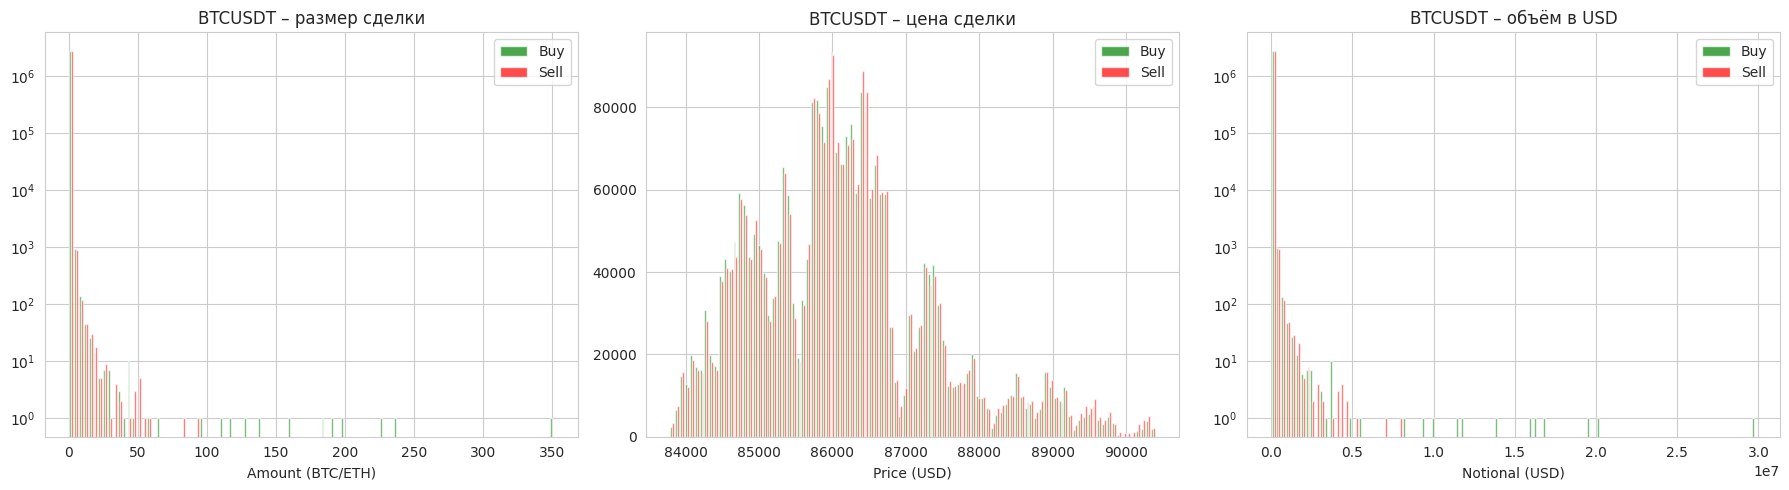


=== BTCUSDT – статистика трейдов ===
             amount         price      notional
count  5.551829e+06  5.551829e+06  5.551829e+06
mean   5.153509e-02  8.614524e+04  4.440241e+03
std    3.798112e-01  1.240759e+03  3.258391e+04
min    1.000000e-03  8.378600e+04  8.378900e+01
25%    2.000000e-03  8.527120e+04  1.748684e+02
50%    3.000000e-03  8.603450e+04  2.603889e+02
75%    1.900000e-02  8.669330e+04  1.609165e+03
max    3.514070e+02  9.039690e+04  2.986924e+07


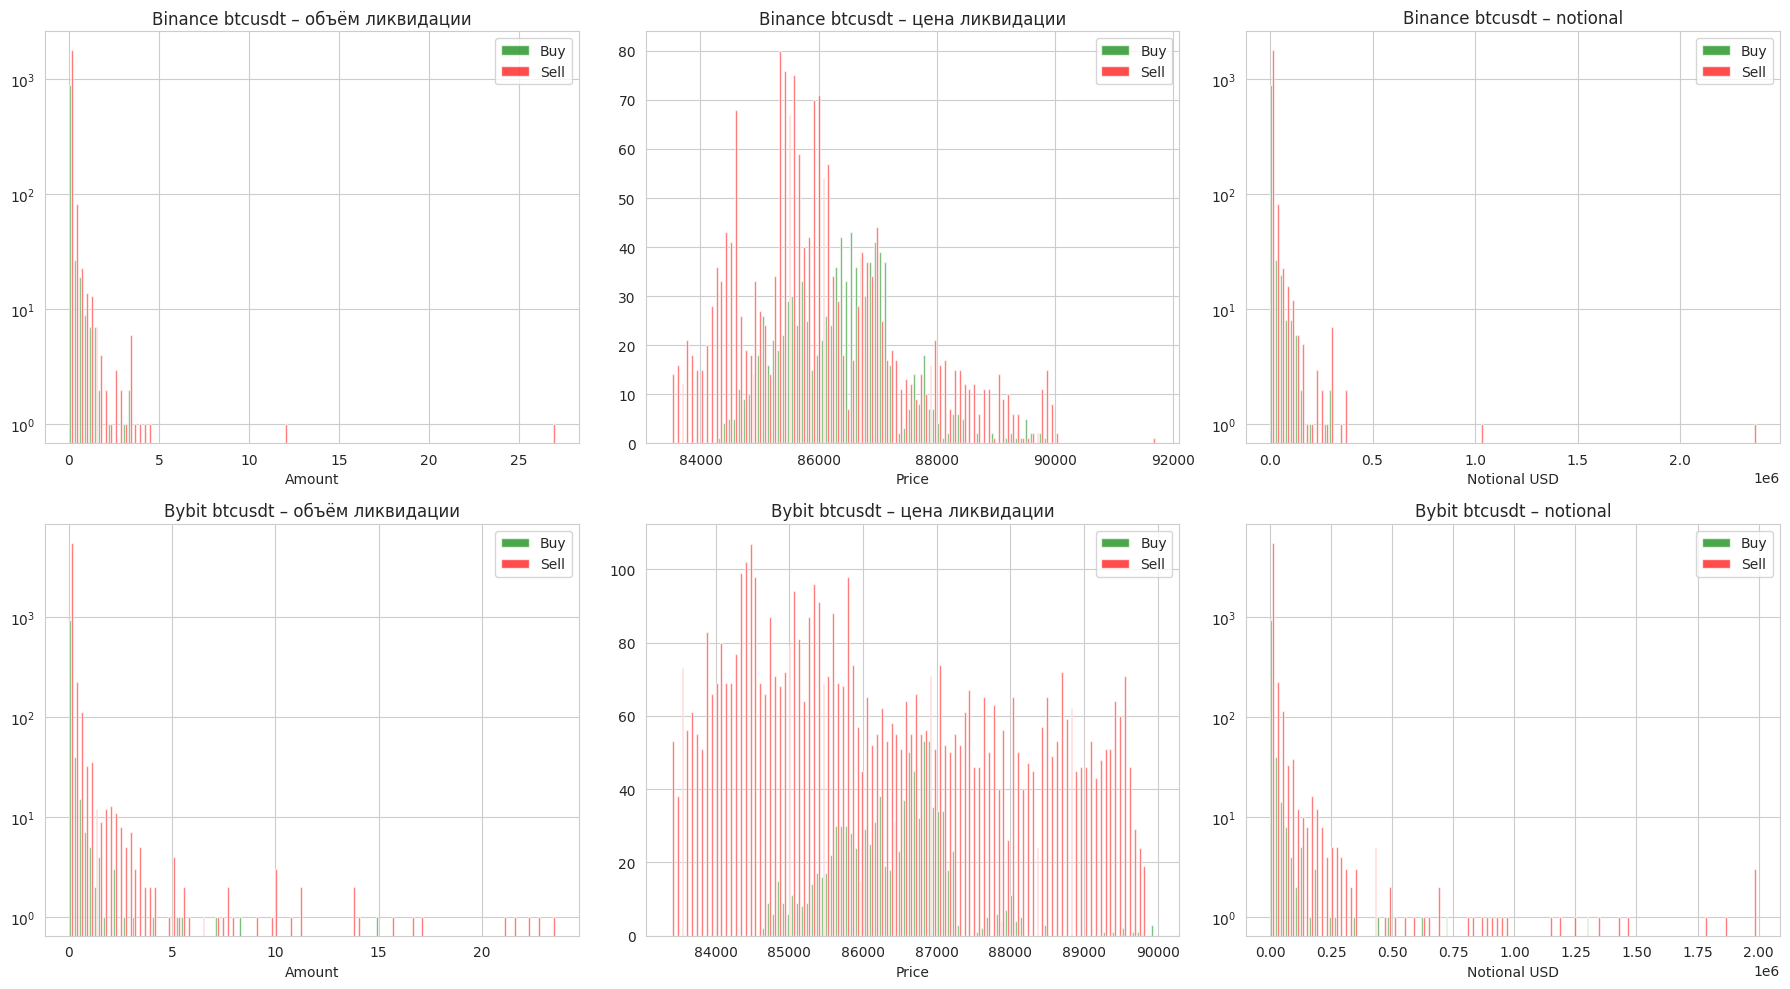

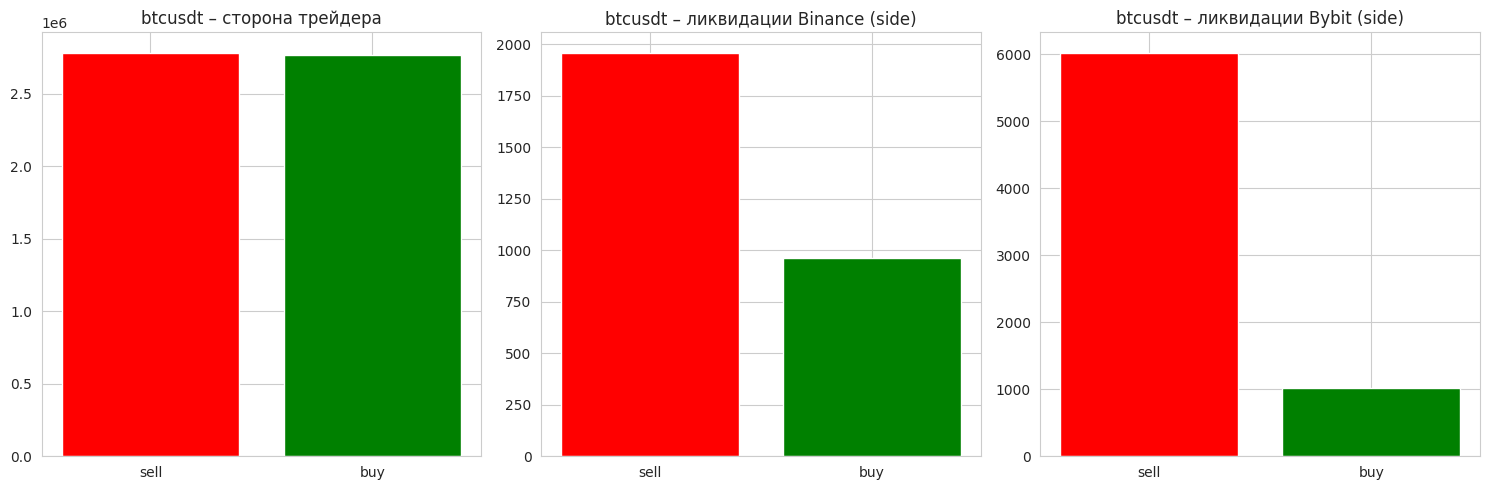

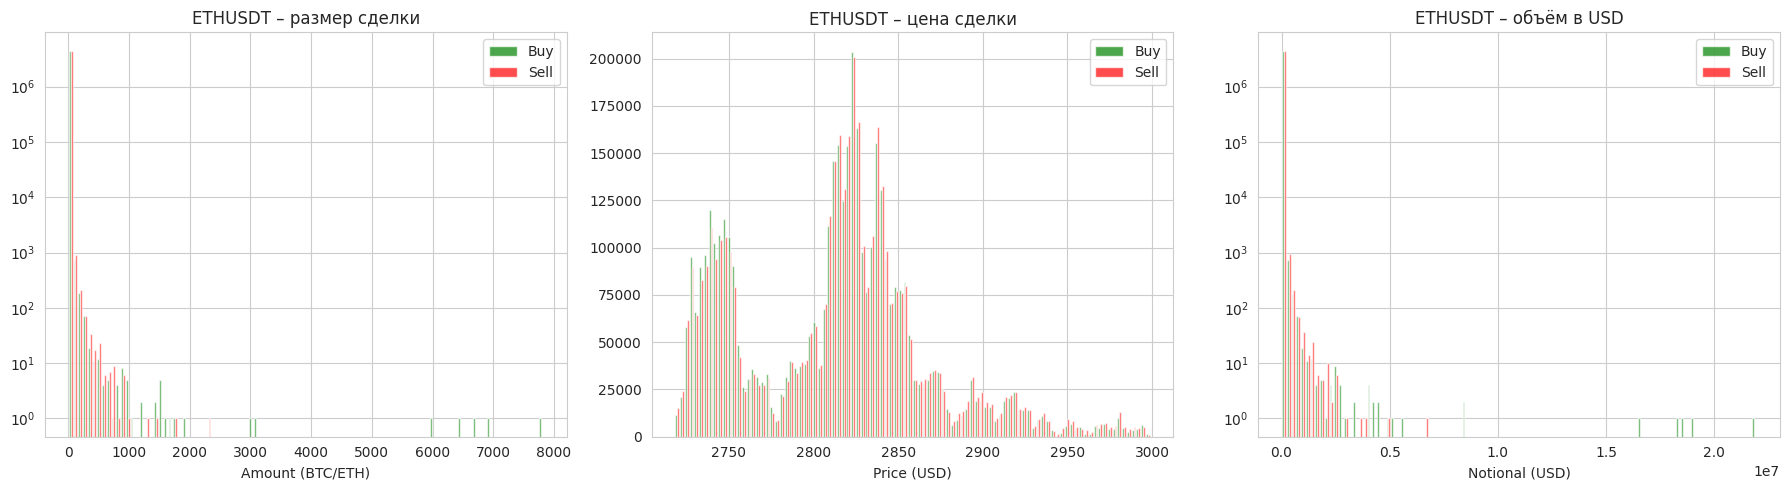


=== ETHUSDT – статистика трейдов ===
             amount         price      notional
count  8.917032e+06  8.917032e+06  8.917032e+06
mean   7.264101e-01  2.812397e+03  2.044015e+03
std    7.088754e+00  5.521813e+01  1.981951e+04
min    1.000000e-03  2.718070e+03  2.718080e+00
25%    1.100000e-02  2.759720e+03  3.010678e+01
50%    4.000000e-02  2.818350e+03  1.133636e+02
75%    2.600000e-01  2.841150e+03  7.314918e+02
max    7.827076e+03  2.998840e+03  2.197060e+07


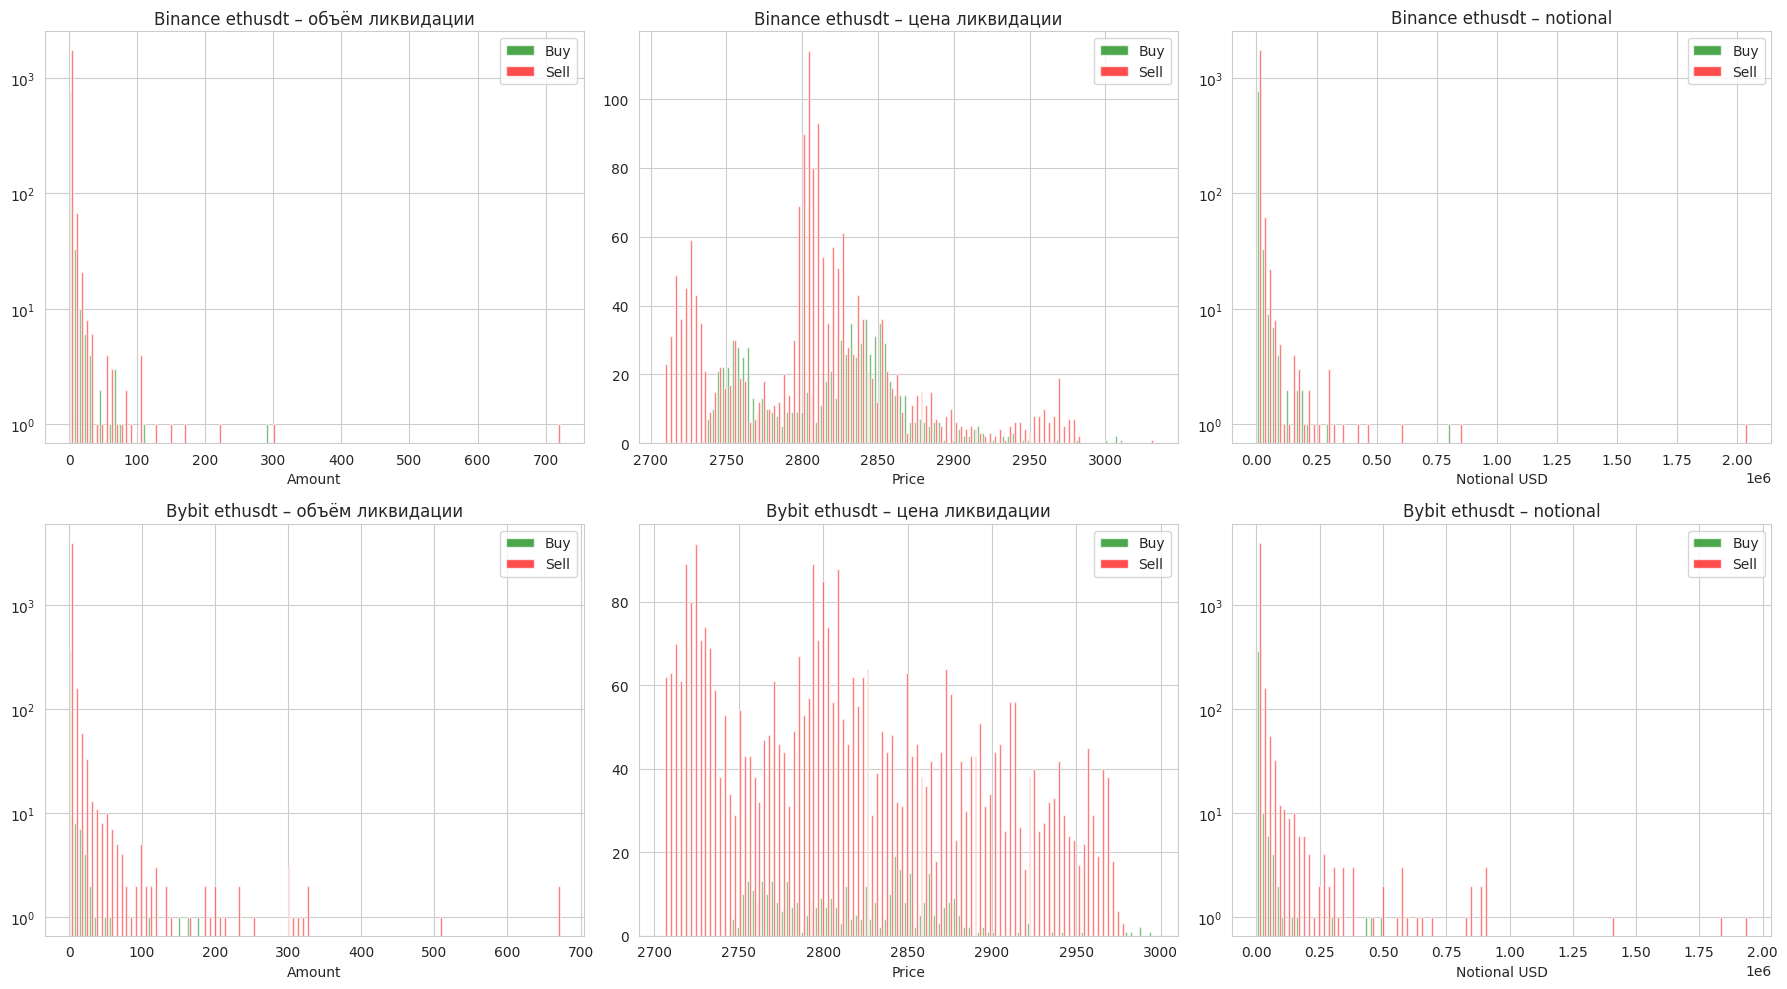

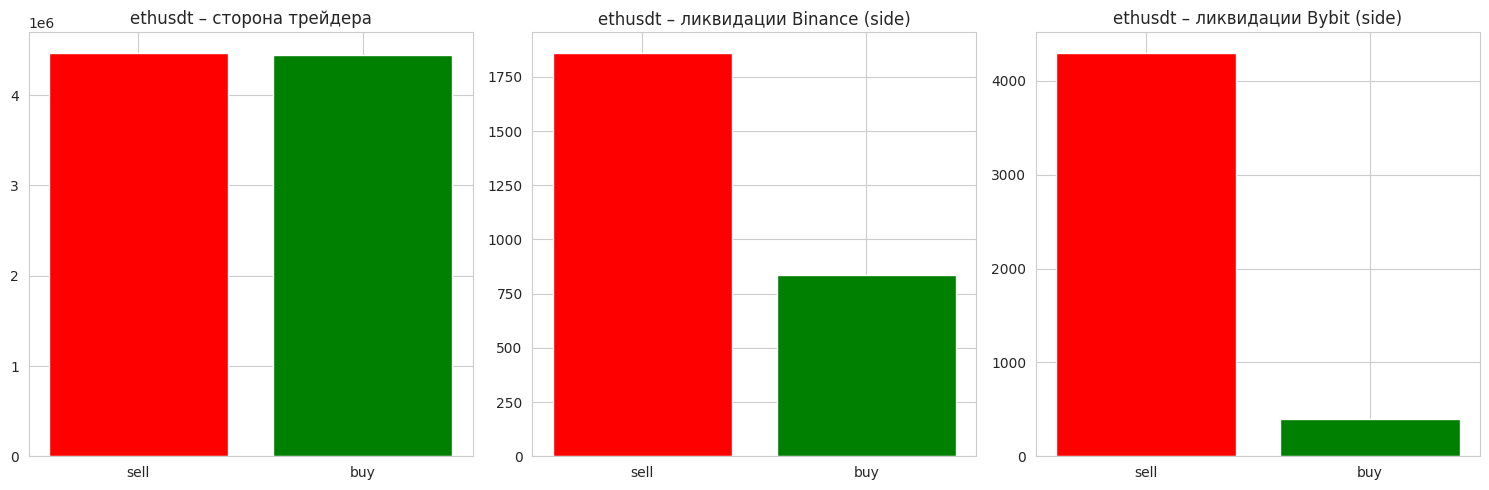

In [ ]:
def plot_trade_distributions(asset):
    trades = data['binance_trades'][asset].copy()
    trades['notional'] = trades['price'] * trades['amount']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Amount (лог. шкала)
    axes[0].hist([trades[trades['side']=='buy']['amount'],
                  trades[trades['side']=='sell']['amount']],
                 bins=100, log=True, alpha=0.7, label=['Buy', 'Sell'], color=['green','red'])
    axes[0].set_title(f'{asset.upper()} – размер сделки')
    axes[0].set_xlabel('Amount (BTC/ETH)')
    axes[0].legend()

    # Price
    axes[1].hist([trades[trades['side']=='buy']['price'],
                  trades[trades['side']=='sell']['price']],
                 bins=100, alpha=0.7, label=['Buy', 'Sell'], color=['green','red'])
    axes[1].set_title(f'{asset.upper()} – цена сделки')
    axes[1].set_xlabel('Price (USD)')
    axes[1].legend()

    # Notional (лог. шкала)
    axes[2].hist([trades[trades['side']=='buy']['notional'],
                  trades[trades['side']=='sell']['notional']],
                 bins=100, log=True, alpha=0.7, label=['Buy', 'Sell'], color=['green','red'])
    axes[2].set_title(f'{asset.upper()} – объём в USD')
    axes[2].set_xlabel('Notional (USD)')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    print(f"\n=== {asset.upper()} – статистика трейдов ===")
    print(trades[['amount','price','notional']].describe())

def plot_liquidation_distributions(asset):
    liq_bin = data['binance_liquidations'][asset].copy()
    liq_byb = data['bybit_liquidations'][asset].copy()

    if liq_bin.empty and liq_byb.empty:
        print(f"Нет данных по ликвидациям для {asset}")
        return

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Binance: amount
    if not liq_bin.empty:
        liq_bin['notional'] = liq_bin['price'] * liq_bin['amount']
        axes[0,0].hist([liq_bin[liq_bin['side']=='buy']['amount'],
                        liq_bin[liq_bin['side']=='sell']['amount']],
                       bins=100, log=True, alpha=0.7, label=['Buy','Sell'], color=['green','red'])
        axes[0,0].set_title(f'Binance {asset} – объём ликвидации')
        axes[0,0].set_xlabel('Amount')
        axes[0,0].legend()

        axes[0,1].hist([liq_bin[liq_bin['side']=='buy']['price'],
                        liq_bin[liq_bin['side']=='sell']['price']],
                       bins=100, alpha=0.7, label=['Buy','Sell'], color=['green','red'])
        axes[0,1].set_title(f'Binance {asset} – цена ликвидации')
        axes[0,1].set_xlabel('Price')
        axes[0,1].legend()

        axes[0,2].hist([liq_bin[liq_bin['side']=='buy']['notional'],
                        liq_bin[liq_bin['side']=='sell']['notional']],
                       bins=100, log=True, alpha=0.7, label=['Buy','Sell'], color=['green','red'])
        axes[0,2].set_title(f'Binance {asset} – notional')
        axes[0,2].set_xlabel('Notional USD')
        axes[0,2].legend()

    # Bybit
    if not liq_byb.empty:
        liq_byb['notional'] = liq_byb['price'] * liq_byb['amount']
        axes[1,0].hist([liq_byb[liq_byb['side']=='buy']['amount'],
                        liq_byb[liq_byb['side']=='sell']['amount']],
                       bins=100, log=True, alpha=0.7, label=['Buy','Sell'], color=['green','red'])
        axes[1,0].set_title(f'Bybit {asset} – объём ликвидации')
        axes[1,0].set_xlabel('Amount')
        axes[1,0].legend()

        axes[1,1].hist([liq_byb[liq_byb['side']=='buy']['price'],
                        liq_byb[liq_byb['side']=='sell']['price']],
                       bins=100, alpha=0.7, label=['Buy','Sell'], color=['green','red'])
        axes[1,1].set_title(f'Bybit {asset} – цена ликвидации')
        axes[1,1].set_xlabel('Price')
        axes[1,1].legend()

        axes[1,2].hist([liq_byb[liq_byb['side']=='buy']['notional'],
                        liq_byb[liq_byb['side']=='sell']['notional']],
                       bins=100, log=True, alpha=0.7, label=['Buy','Sell'], color=['green','red'])
        axes[1,2].set_title(f'Bybit {asset} – notional')
        axes[1,2].set_xlabel('Notional USD')
        axes[1,2].legend()

    plt.tight_layout()
    plt.show()

def plot_side_distributions(asset):
    trades = data['binance_trades'][asset]
    liq_bin = data['binance_liquidations'][asset]
    liq_byb = data['bybit_liquidations'][asset]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Trades
    side_counts = trades['side'].value_counts()
    axes[0].bar(side_counts.index, side_counts.values, color=['red','green'])
    axes[0].set_title(f'{asset} – сторона трейдера')

    # Binance liq
    if not liq_bin.empty:
        liq_side = liq_bin['side'].value_counts()
        axes[1].bar(liq_side.index, liq_side.values, color=['red','green'])
    axes[1].set_title(f'{asset} – ликвидации Binance (side)')

    # Bybit liq
    if not liq_byb.empty:
        byb_side = liq_byb['side'].value_counts()
        axes[2].bar(byb_side.index, byb_side.values, color=['red','green'])
    axes[2].set_title(f'{asset} – ликвидации Bybit (side)')

    plt.tight_layout()
    plt.show()

for sym in SYMBOLS:
    plot_trade_distributions(sym)
    plot_liquidation_distributions(sym)
    plot_side_distributions(sym)

### Basic Cross-Exchange Comparison

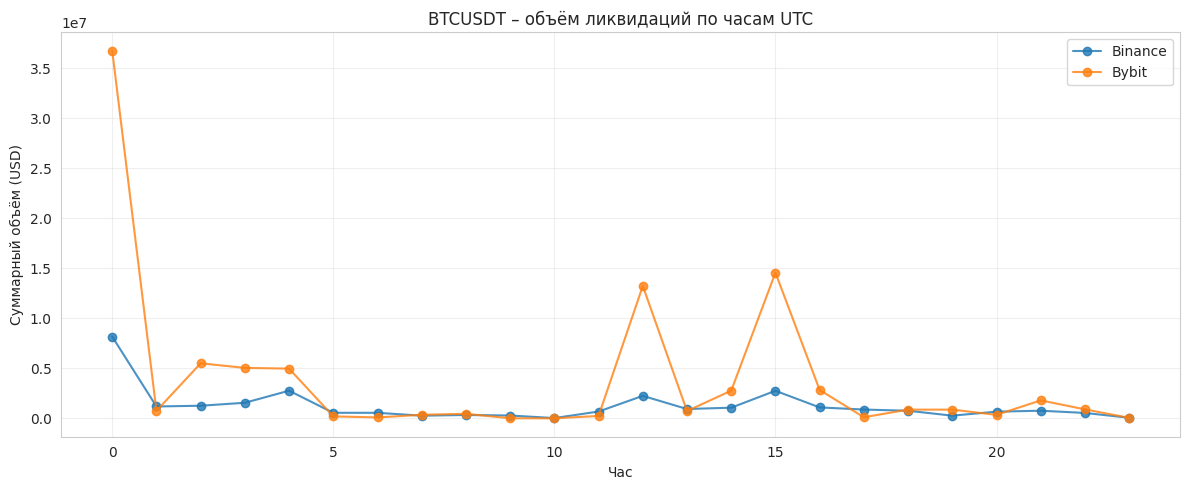

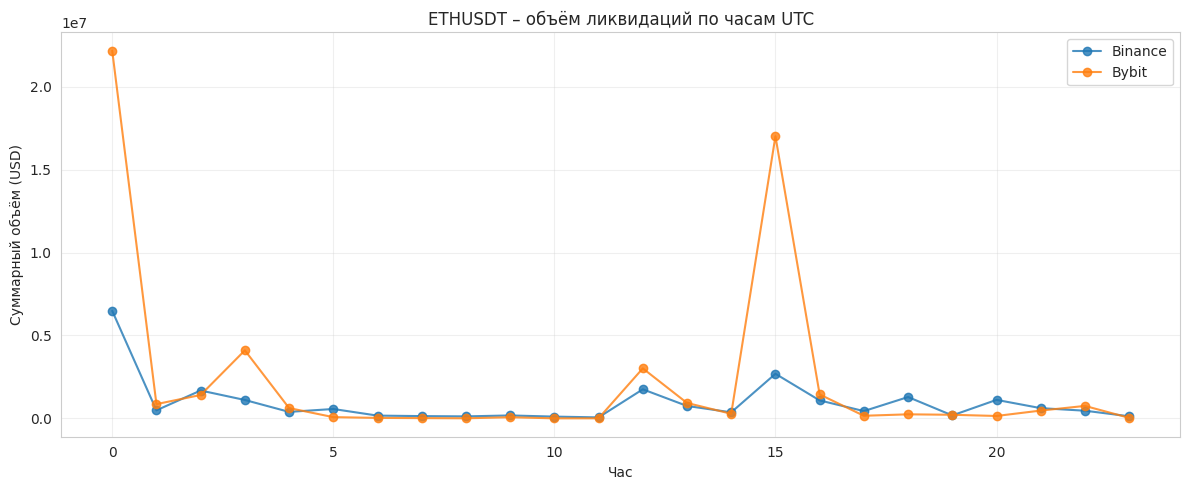

In [ ]:
def plot_liquidation_volume_by_hour(asset, exchange='both'):
    """exchange: 'binance', 'bybit', 'both'"""
    fig, ax = plt.subplots(figsize=(12, 5))

    for exch in ['binance', 'bybit']:
        if exchange != 'both' and exch != exchange:
            continue
        liq = data[f'{exch}_liquidations'][asset].copy()
        if liq.empty:
            continue
        liq['notional'] = liq['price'] * liq['amount']
        liq['hour'] = liq['datetime'].dt.hour
        vol_by_hour = liq.groupby('hour')['notional'].sum()
        vol_by_hour = vol_by_hour.reindex(range(24), fill_value=0)
        ax.plot(vol_by_hour.index, vol_by_hour.values, marker='o',
                label=exch.capitalize(), alpha=0.8)

    ax.set_title(f'{asset.upper()} – объём ликвидаций по часам UTC')
    ax.set_xlabel('Час')
    ax.set_ylabel('Суммарный объём (USD)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

for sym in SYMBOLS:
    plot_liquidation_volume_by_hour(sym, exchange='both')

In [ ]:
print("\n=== Сравнение количества и объёма ликвидаций ===")
for sym in SYMBOLS:
    bin_liq = data['binance_liquidations'][sym]
    byb_liq = data['bybit_liquidations'][sym]

    bin_volume = (bin_liq['price'] * bin_liq['amount']).sum() if not bin_liq.empty else 0
    byb_volume = (byb_liq['price'] * byb_liq['amount']).sum() if not byb_liq.empty else 0

    print(f"\n{sym.upper()}:")
    print(f"  Binance: {len(bin_liq):,} ликвидаций, объём = {bin_volume:,.2f} USD")
    print(f"  Bybit:   {len(byb_liq):,} ликвидаций, объём = {byb_volume:,.2f} USD")


=== Сравнение количества и объёма ликвидаций ===

BTCUSDT:
  Binance: 2,922 ликвидаций, объём = 29,673,692.18 USD
  Bybit:   7,042 ликвидаций, объём = 93,423,841.17 USD

ETHUSDT:
  Binance: 2,699 ликвидаций, объём = 22,310,014.06 USD
  Bybit:   4,696 ликвидаций, объём = 54,030,858.69 USD


## Task 1.2 Intermediate Analysis

### Broad market EDA  

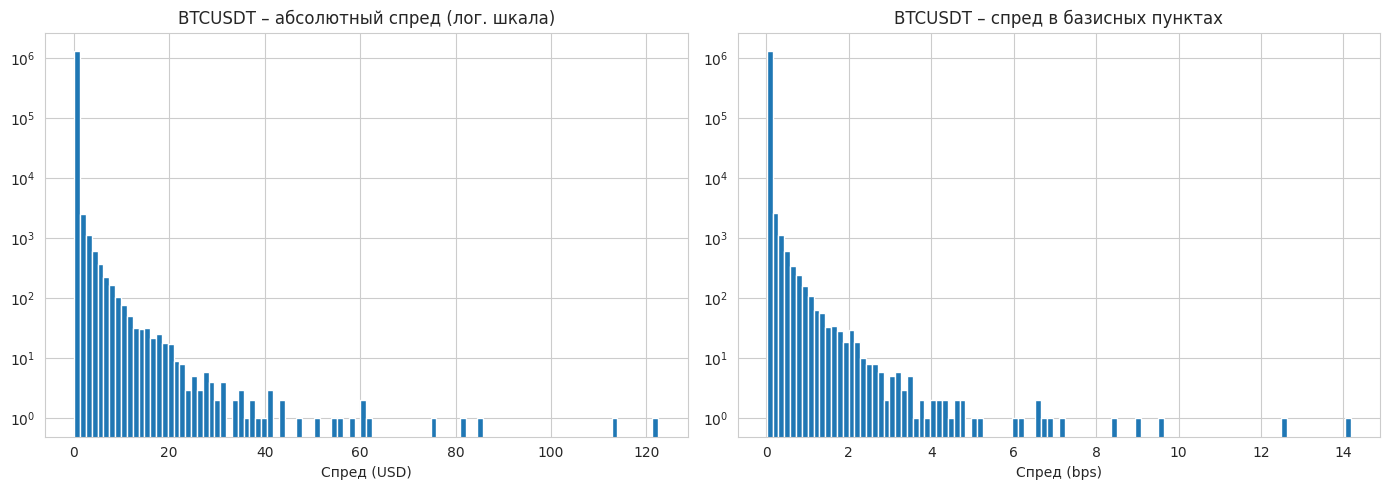

Средний спред BTCUSDT: 0.1216 USD / 0.01 bps


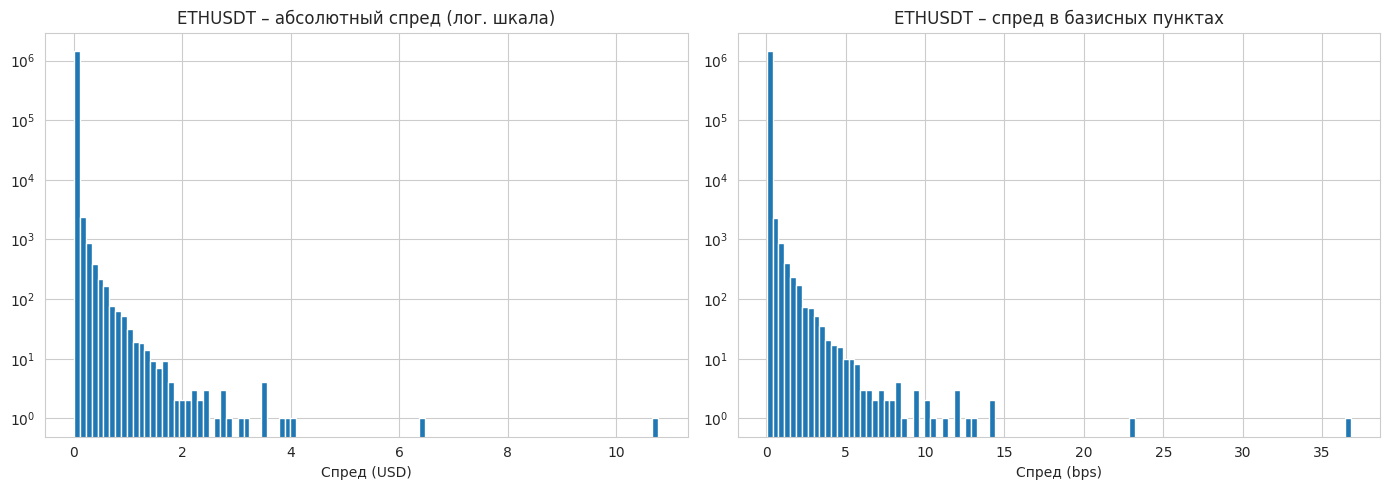

Средний спред ETHUSDT: 0.0112 USD / 0.04 bps


In [ ]:
def plot_spread(asset):
    bbo = data['binance_bbo'][asset].copy()
    bbo['spread'] = bbo['ask_price'] - bbo['bid_price']
    bbo['mid'] = (bbo['ask_price'] + bbo['bid_price']) / 2
    bbo['spread_bps'] = bbo['spread'] / bbo['mid'] * 10_000

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(bbo['spread'], bins=100, log=True)
    axes[0].set_title(f'{asset.upper()} – абсолютный спред (лог. шкала)')
    axes[0].set_xlabel('Спред (USD)')

    axes[1].hist(bbo['spread_bps'], bins=100, log=True)
    axes[1].set_title(f'{asset.upper()} – спред в базисных пунктах')
    axes[1].set_xlabel('Спред (bps)')
    plt.tight_layout()
    plt.show()

    print(f"Средний спред {asset.upper()}: {bbo['spread'].mean():.4f} USD / {bbo['spread_bps'].mean():.2f} bps")

for sym in SYMBOLS:
    plot_spread(sym)


=== BTCUSDT – статистика трейдов ===
Всего сделок: 5,551,829
Taker buy: 2,767,669 | Taker sell: 2,784,160
Средний notional: 4440.24 USD
Медианный notional: 260.39 USD
95-й перцентиль notional: 20634.84 USD


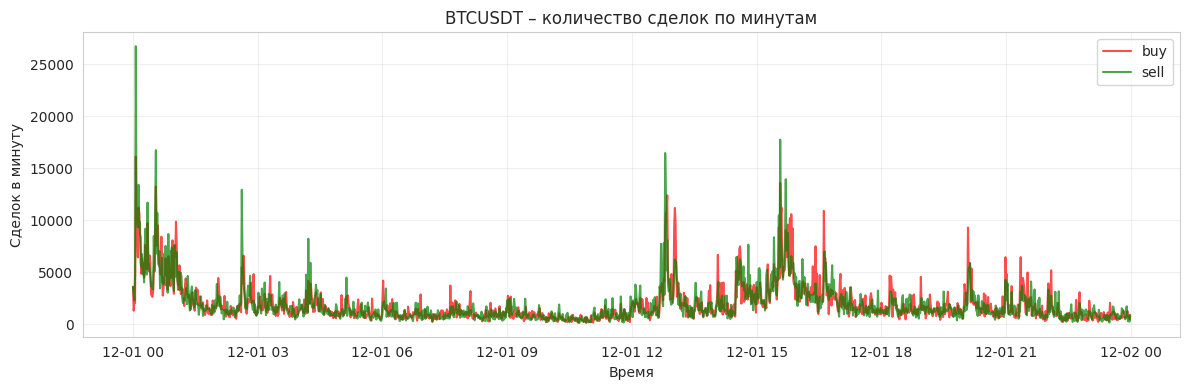


=== ETHUSDT – статистика трейдов ===
Всего сделок: 8,917,032
Taker buy: 4,443,937 | Taker sell: 4,473,095
Средний notional: 2044.01 USD
Медианный notional: 113.36 USD
95-й перцентиль notional: 10385.84 USD


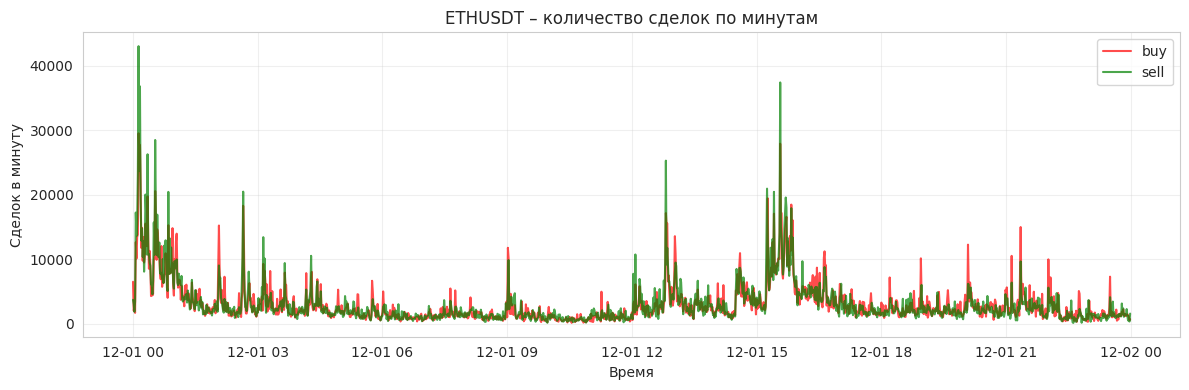

In [ ]:
def trade_stats_and_frequency(asset):
    trades = data['binance_trades'][asset].copy()
    trades['notional'] = trades['price'] * trades['amount']

    print(f"\n=== {asset.upper()} – статистика трейдов ===")
    print(f"Всего сделок: {len(trades):,}")
    print(f"Taker buy: {(trades['side']=='buy').sum():,} | Taker sell: {(trades['side']=='sell').sum():,}")
    print(f"Средний notional: {trades['notional'].mean():.2f} USD")
    print(f"Медианный notional: {trades['notional'].median():.2f} USD")
    print(f"95-й перцентиль notional: {trades['notional'].quantile(0.95):.2f} USD")

    # Частота по минутам
    trades['minute'] = trades['datetime'].dt.floor('1min')
    freq = trades.groupby(['side', 'minute']).size().reset_index(name='count')

    plt.figure(figsize=(12, 4))
    for side, color in [('buy','red'), ('sell','green')]:
        data_side = freq[freq['side']==side]
        if not data_side.empty:
            plt.plot(data_side['minute'], data_side['count'], color=color, alpha=0.7, label=side)
    plt.title(f'{asset.upper()} – количество сделок по минутам')
    plt.xlabel('Время')
    plt.ylabel('Сделок в минуту')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

for sym in SYMBOLS:
    trade_stats_and_frequency(sym)

### ML EDA  

In [ ]:
def shift_bybit(liq_df, shift_ms=200):
    """Сдвигает timestamp ликвидаций Bybit вперёд на заданное число мс."""
    liq_shifted = liq_df.copy()
    liq_shifted['timestamp'] = liq_shifted['timestamp'] + shift_ms * 1000
    liq_shifted['datetime'] = pd.to_datetime(liq_shifted['timestamp'], unit='us')
    return liq_shifted

byb_liq_btc_shifted = shift_bybit(data['bybit_liquidations']['btcusdt'])
byb_liq_eth_shifted = shift_bybit(data['bybit_liquidations']['ethusdt'])

In [ ]:
freq = '1min'

# BBO
bbo = data['binance_bbo']['btcusdt'].copy()
bbo['mid'] = (bbo['bid_price'] + bbo['ask_price']) / 2
bbo['spread'] = bbo['ask_price'] - bbo['bid_price']
bbo['bid_ask_diff'] = bbo['bid_amount'] - bbo['ask_amount']
bbo.set_index('datetime', inplace=True)
bbo_resampled = bbo.resample(freq).agg({
    'mid': 'last',
    'spread': 'last',
    'bid_amount': 'last',
    'ask_amount': 'last',
    'bid_ask_diff': 'last'
}).dropna()

# Trades
trades = data['binance_trades']['btcusdt'].copy()
trades['notional'] = trades['price'] * trades['amount']
trades_agg = trades.groupby([pd.Grouper(key='datetime', freq=freq), 'side']).agg({
    'price': 'mean', 'amount': 'sum', 'notional': 'sum'
}).unstack(fill_value=0)
trades_agg.columns = [f'{stat}_{side}' for stat, side in trades_agg.columns]

# Ликвидации (Binance и Bybit со сдвигом)
def aggregate_liquidations(liq_df, name):
    liq = liq_df.copy()
    liq['notional'] = liq['price'] * liq['amount']
    liq_buy = liq[liq['side']=='buy'].groupby(pd.Grouper(key='datetime', freq=freq)).agg(
        {'price':'mean','amount':'sum','notional':'sum'}).add_suffix(f'_{name}_buy')
    liq_sell = liq[liq['side']=='sell'].groupby(pd.Grouper(key='datetime', freq=freq)).agg(
        {'price':'mean','amount':'sum','notional':'sum'}).add_suffix(f'_{name}_sell')
    return pd.concat([liq_buy, liq_sell], axis=1).fillna(0)

liq_bin_agg = aggregate_liquidations(data['binance_liquidations']['btcusdt'], 'binance')
liq_byb_agg = aggregate_liquidations(byb_liq_btc_shifted, 'bybit')

# Счётчики ликвидаций (количество событий)
liq_bin_cnt = data['binance_liquidations']['btcusdt'].copy()
liq_bin_cnt['datetime'] = pd.to_datetime(liq_bin_cnt['timestamp'], unit='us')
liq_bin_cnt = liq_bin_cnt.groupby([pd.Grouper(key='datetime', freq=freq), 'side']).size().unstack(fill_value=0)
liq_bin_cnt.columns = [f'liq_bin_count_{col}' for col in liq_bin_cnt.columns]

liq_byb_cnt = byb_liq_btc_shifted.copy()
liq_byb_cnt = liq_byb_cnt.groupby([pd.Grouper(key='datetime', freq=freq), 'side']).size().unstack(fill_value=0)
liq_byb_cnt.columns = [f'liq_byb_count_{col}' for col in liq_byb_cnt.columns]

# Объединяем всё в один DataFrame
df_features = bbo_resampled.join(trades_agg, how='outer') \
                           .join(liq_bin_agg, how='outer') \
                           .join(liq_byb_agg, how='outer') \
                           .join(liq_bin_cnt) \
                           .join(liq_byb_cnt)
df_features.ffill(inplace=True)   # forward fill для пропусков
df_features['volatility'] = df_features['mid'].pct_change().rolling(60).std()

print(f"Размер признакового датасета: {df_features.shape}")
print(f"Колонки: {list(df_features.columns)}")

Размер признакового датасета: (1440, 28)
Колонки: ['mid', 'spread', 'bid_amount', 'ask_amount', 'bid_ask_diff', 'price_buy', 'price_sell', 'amount_buy', 'amount_sell', 'notional_buy', 'notional_sell', 'price_binance_buy', 'amount_binance_buy', 'notional_binance_buy', 'price_binance_sell', 'amount_binance_sell', 'notional_binance_sell', 'price_bybit_buy', 'amount_bybit_buy', 'notional_bybit_buy', 'price_bybit_sell', 'amount_bybit_sell', 'notional_bybit_sell', 'liq_bin_count_buy', 'liq_bin_count_sell', 'liq_byb_count_buy', 'liq_byb_count_sell', 'volatility']


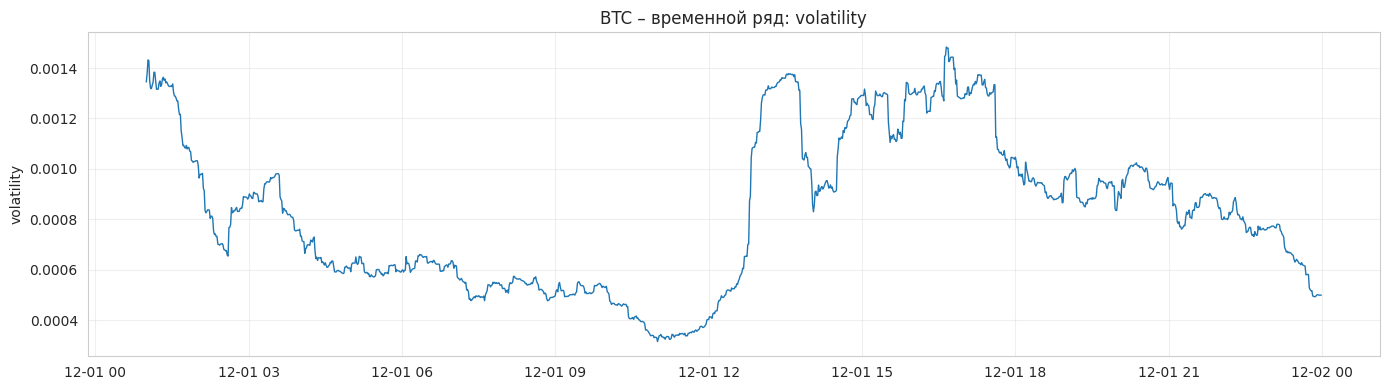

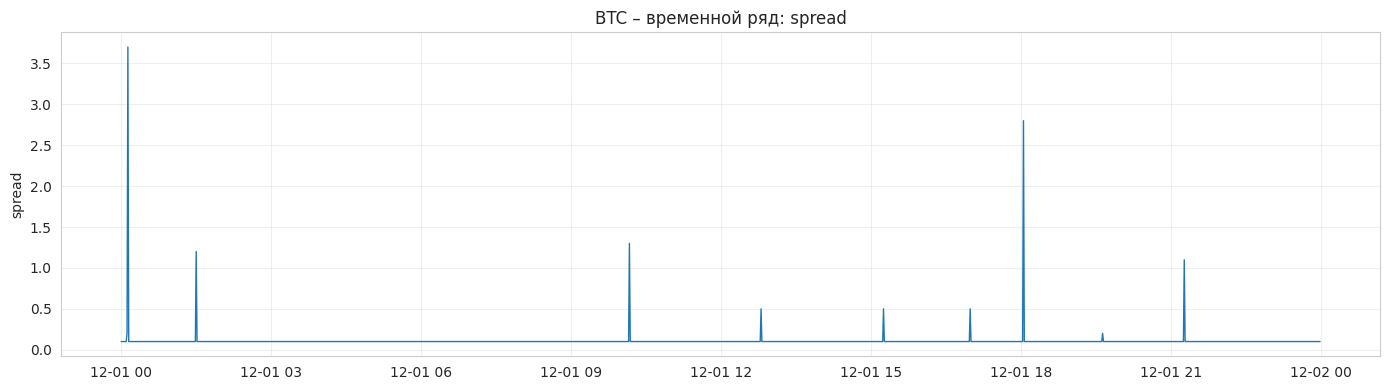

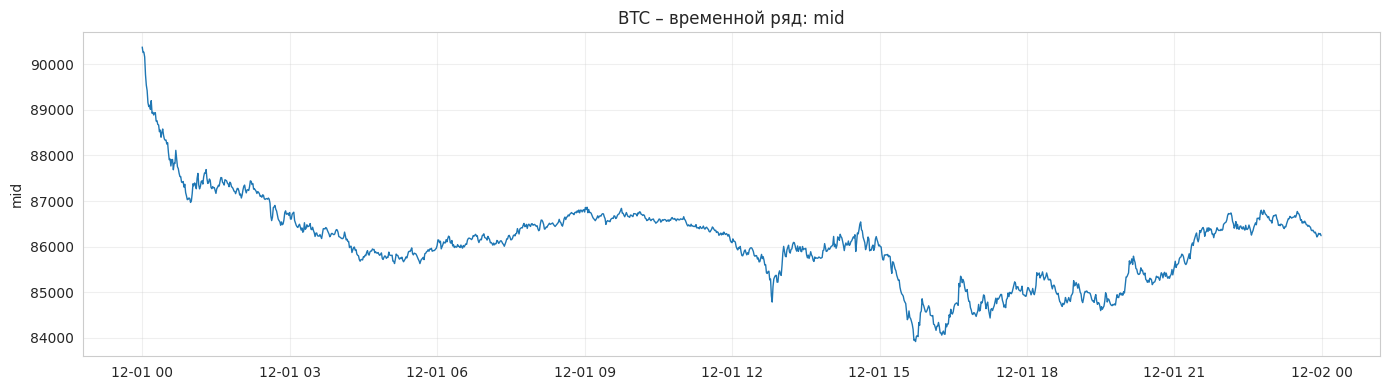

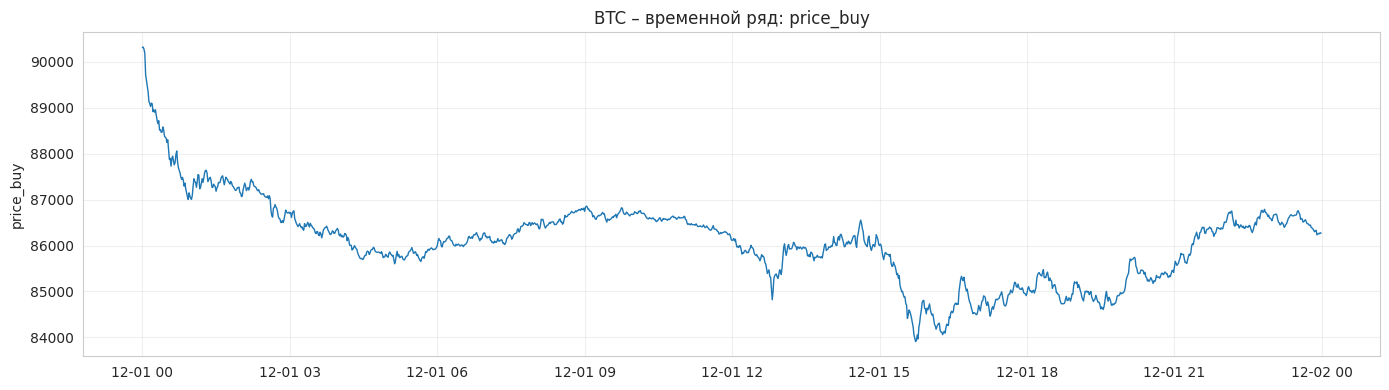

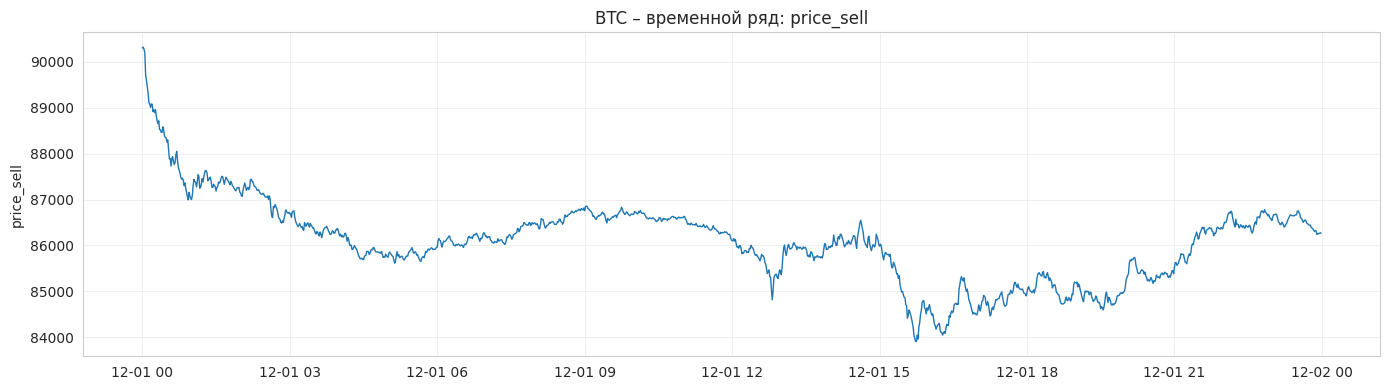

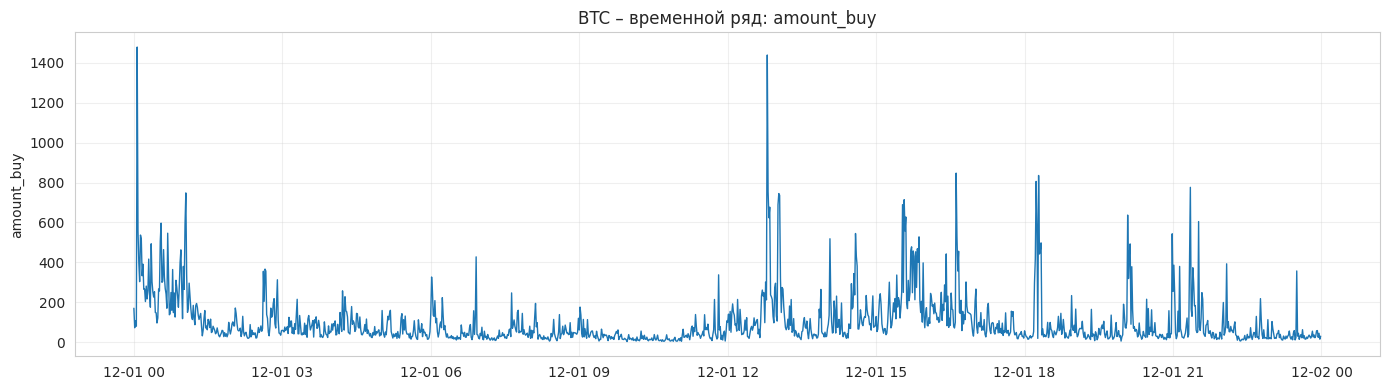

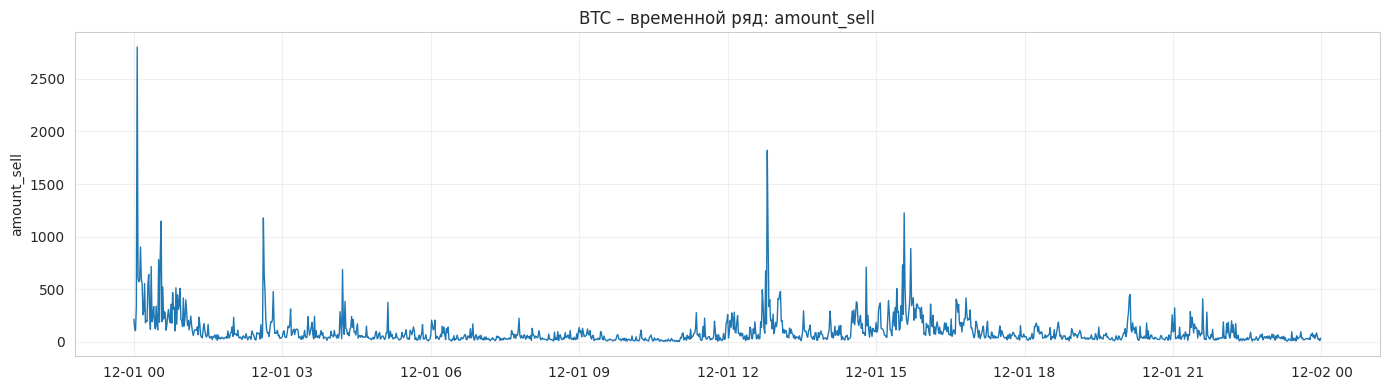

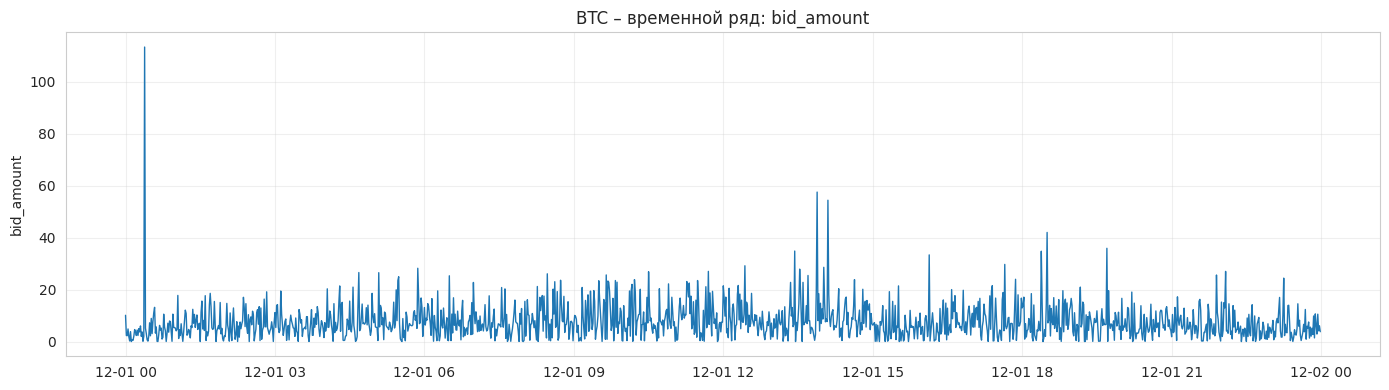

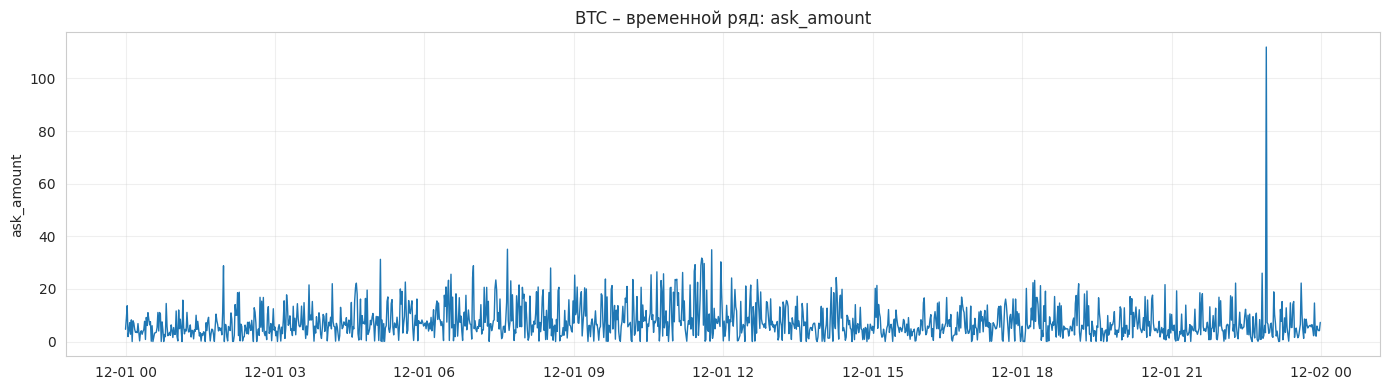

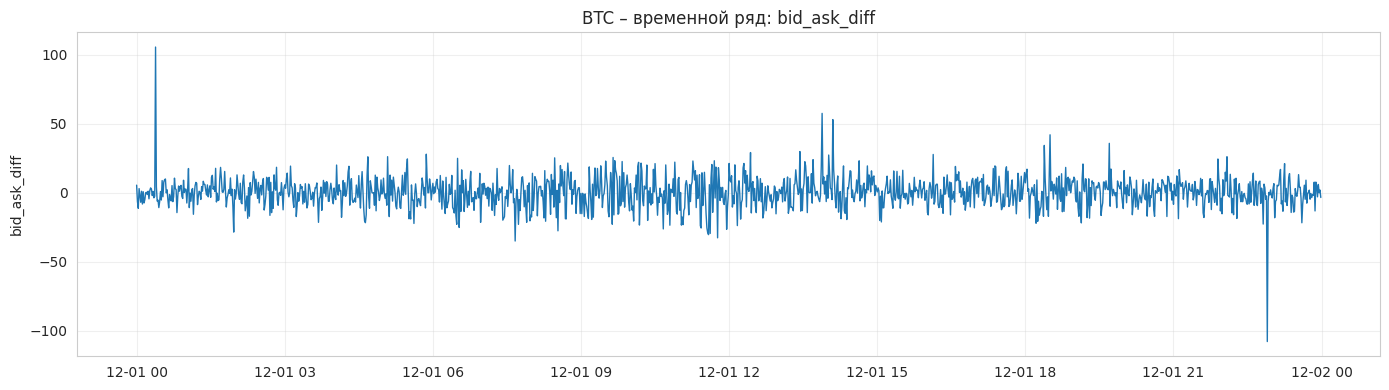

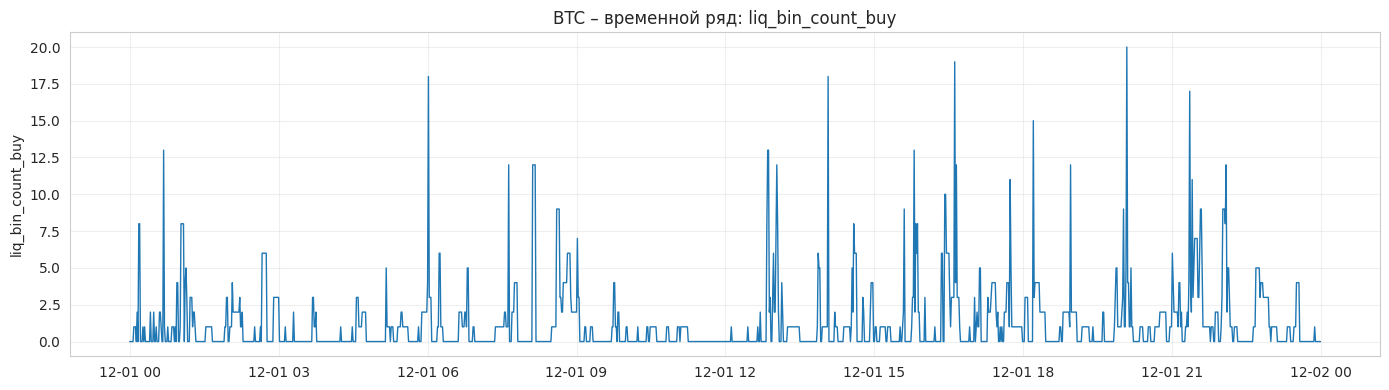

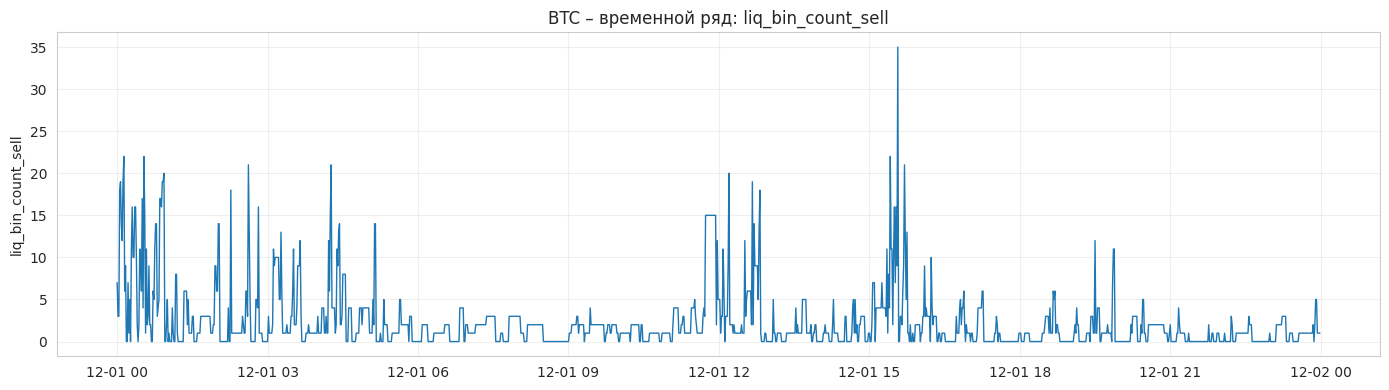

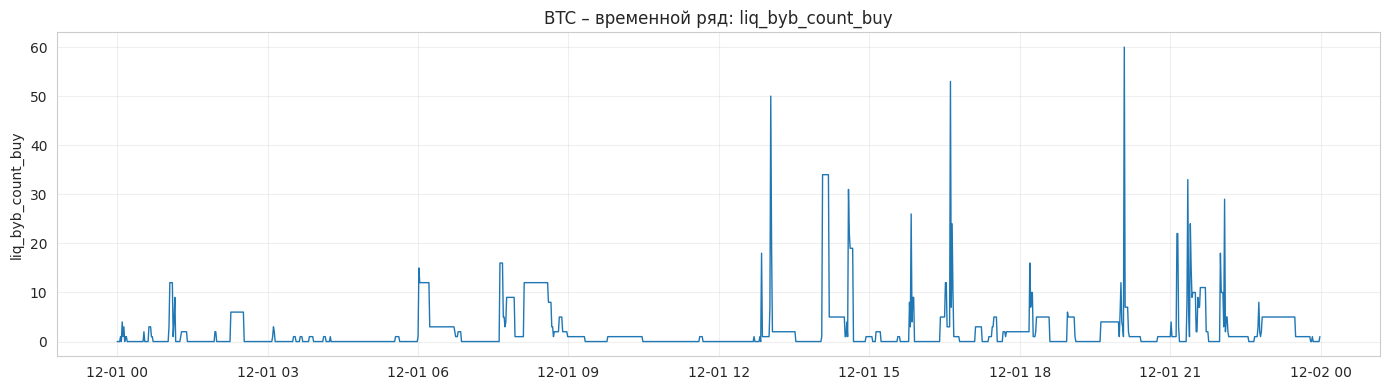

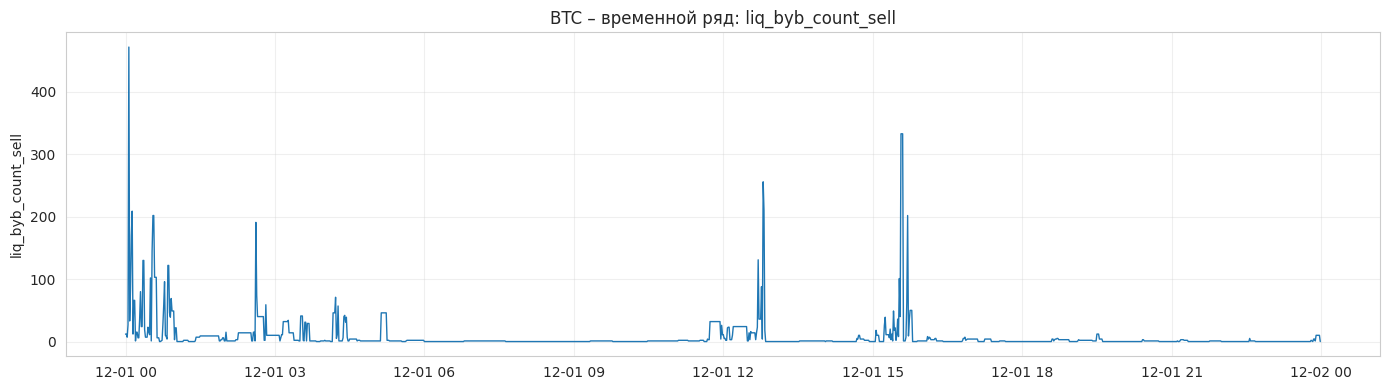

In [ ]:
features_to_plot = [
    'volatility', 'spread', 'mid',
    'price_buy', 'price_sell',
    'amount_buy', 'amount_sell',
    'bid_amount', 'ask_amount', 'bid_ask_diff',
    'liq_bin_count_buy', 'liq_bin_count_sell',
    'liq_byb_count_buy', 'liq_byb_count_sell'
]

for col in features_to_plot:
    if col in df_features.columns:
        plt.figure(figsize=(14, 4))
        plt.plot(df_features.index, df_features[col], linewidth=1)
        plt.title(f'BTC – временной ряд: {col}')
        plt.ylabel(col)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Колонка {col} отсутствует")

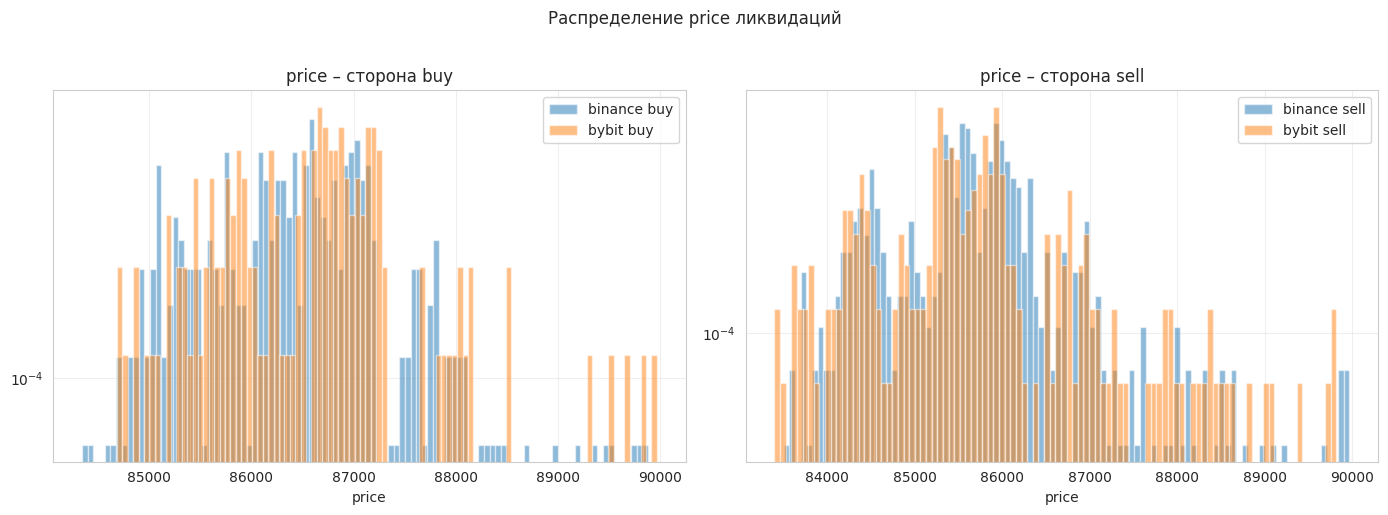

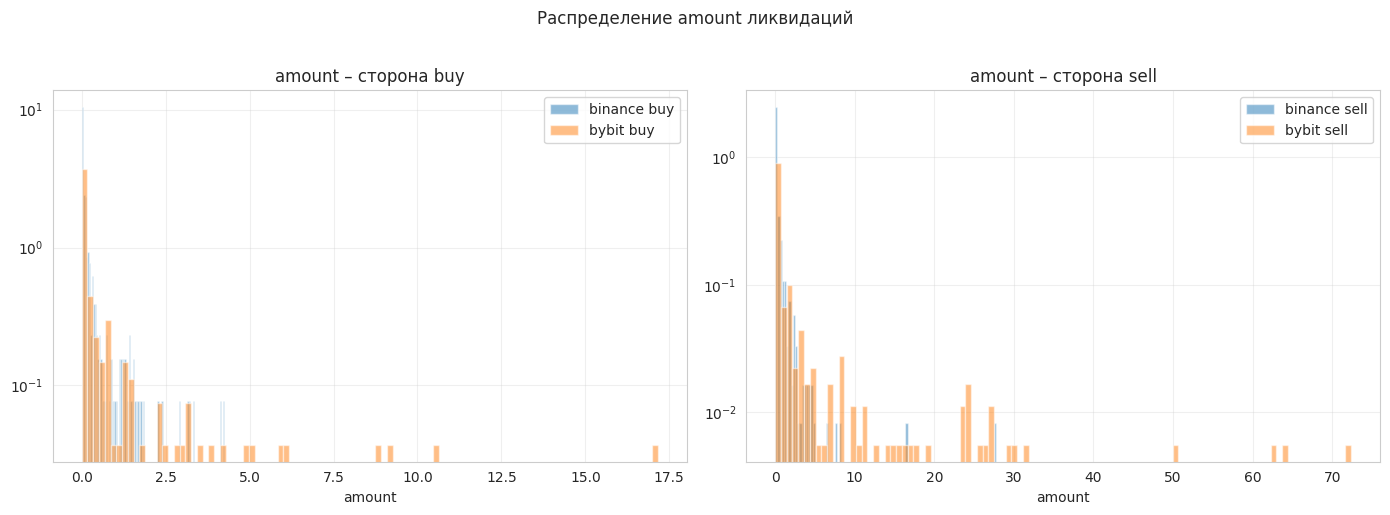

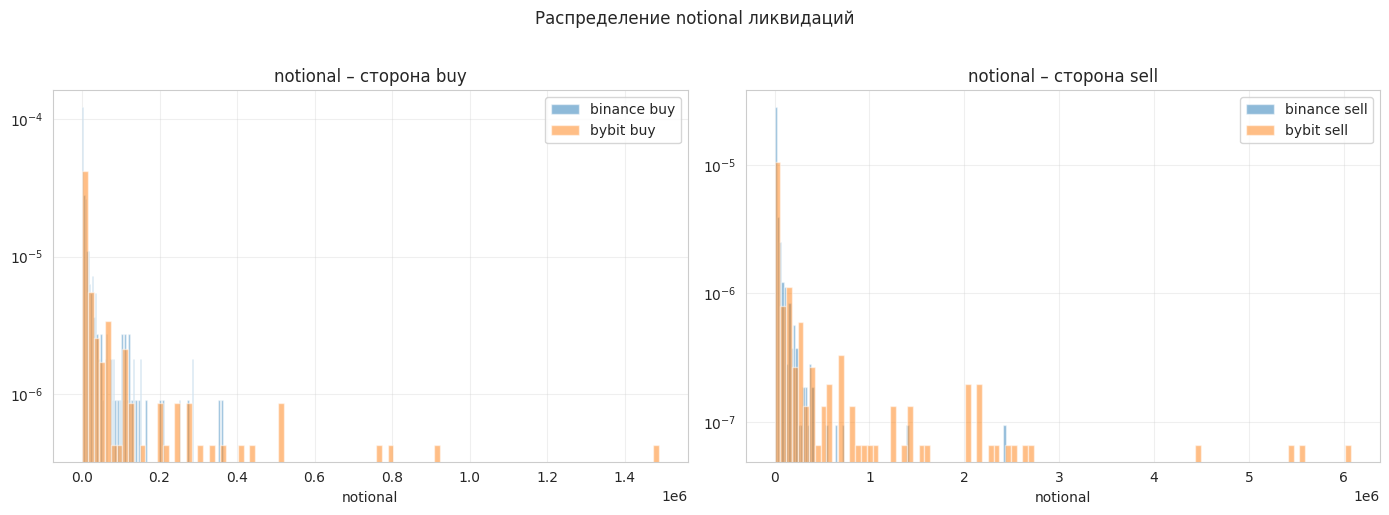

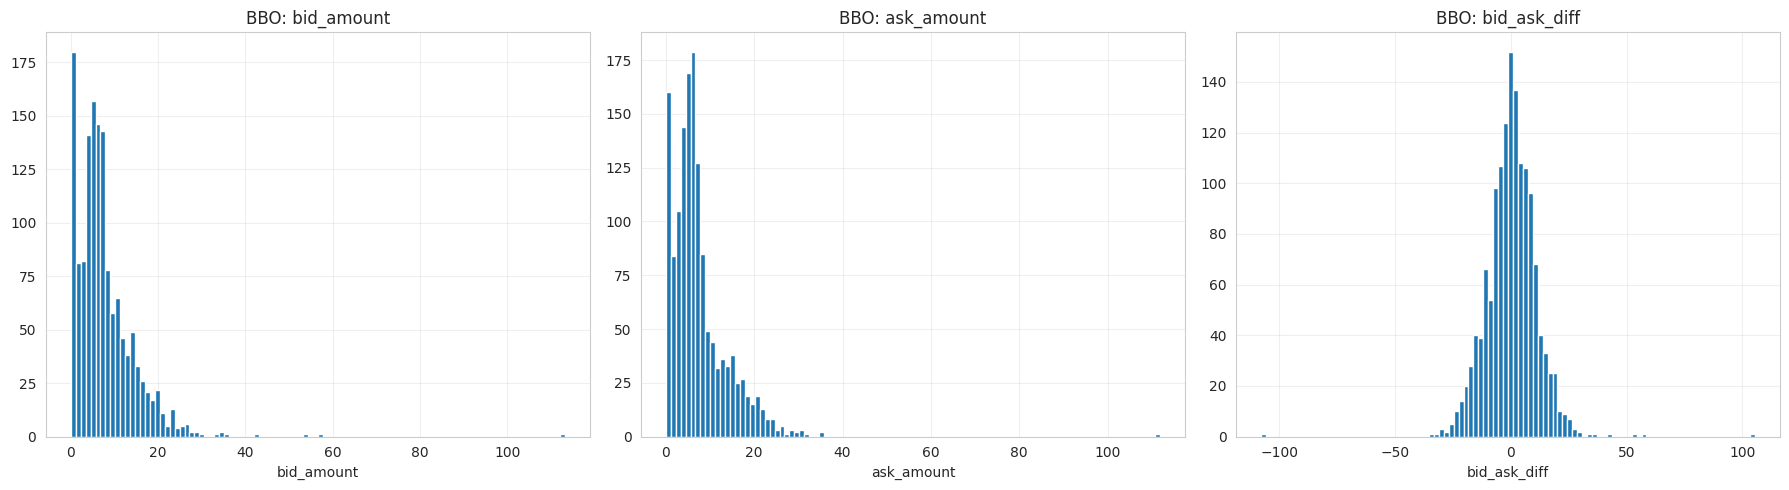

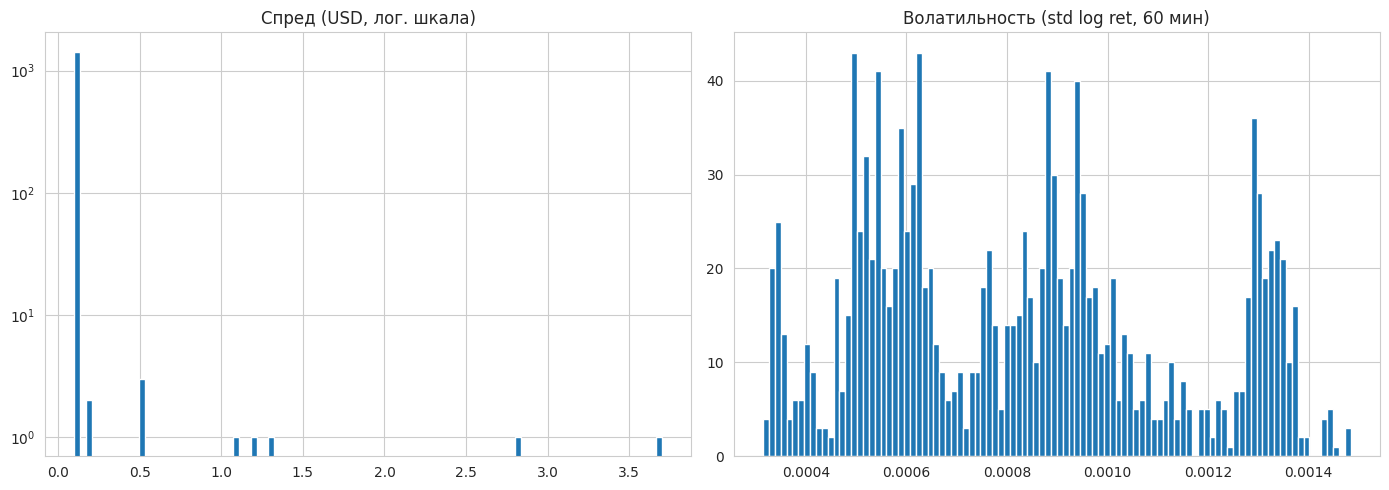

In [ ]:
for base in ['price', 'amount', 'notional']:
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    for idx, side in enumerate(['buy','sell']):
        ax = axes[idx]
        for source in ['binance','bybit']:
            col = f'{base}_{source}_{side}'
            if col in df_features.columns:
                vals = df_features[col].dropna()
                if len(vals) > 0:
                    vals = vals[vals != 0]
                    if len(vals) > 0:  # повторная проверка после фильтрации
                        ax.hist(vals, bins=100, alpha=0.5, density=True, label=f'{source} {side}')
        ax.set_title(f'{base} – сторона {side}')
        ax.set_xlabel(base)
        ax.set_yscale('log')
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.suptitle(f'Распределение {base} ликвидаций', y=1.02)
    plt.tight_layout()
    plt.show()

# Стаканные величины
book_cols = ['bid_amount', 'ask_amount', 'bid_ask_diff']
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for idx, col in enumerate(book_cols):
    axes[idx].hist(df_features[col].dropna(), bins=100)
    axes[idx].set_title(f'BBO: {col}')
    axes[idx].set_xlabel(col)
    axes[idx].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Спред и волатильность
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].hist(df_features['spread'].dropna(), bins=100, log=True)
axes[0].set_title('Спред (USD, лог. шкала)')
axes[1].hist(df_features['volatility'].dropna(), bins=100)
axes[1].set_title('Волатильность (std log ret, 60 мин)')
plt.tight_layout()
plt.show()

## Task 1.3 – Advanced Exploration

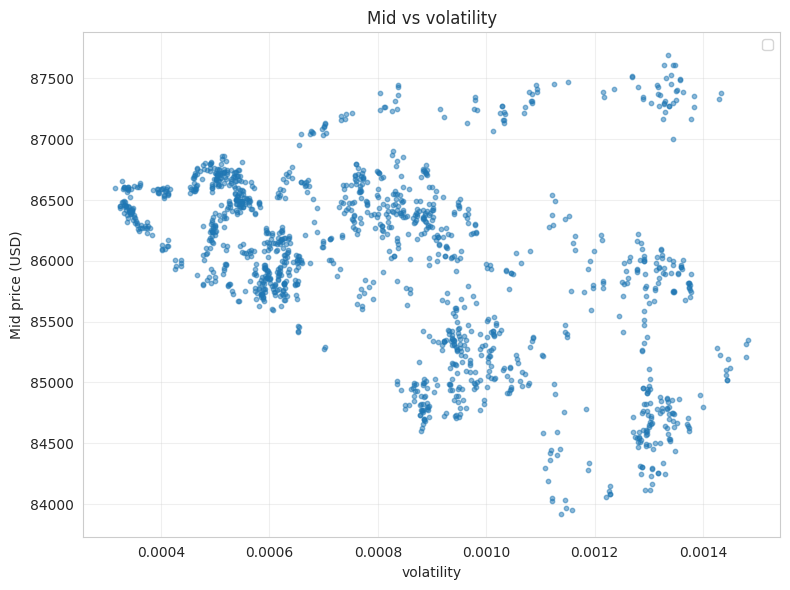

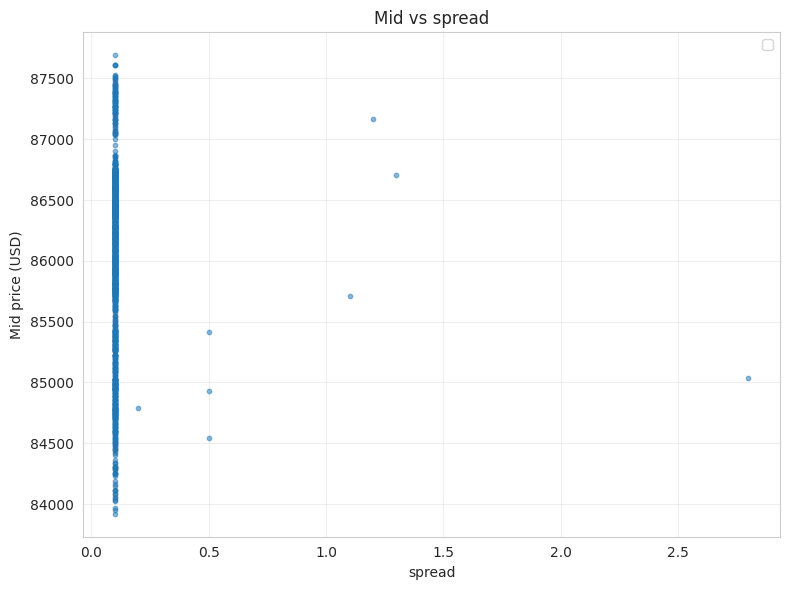

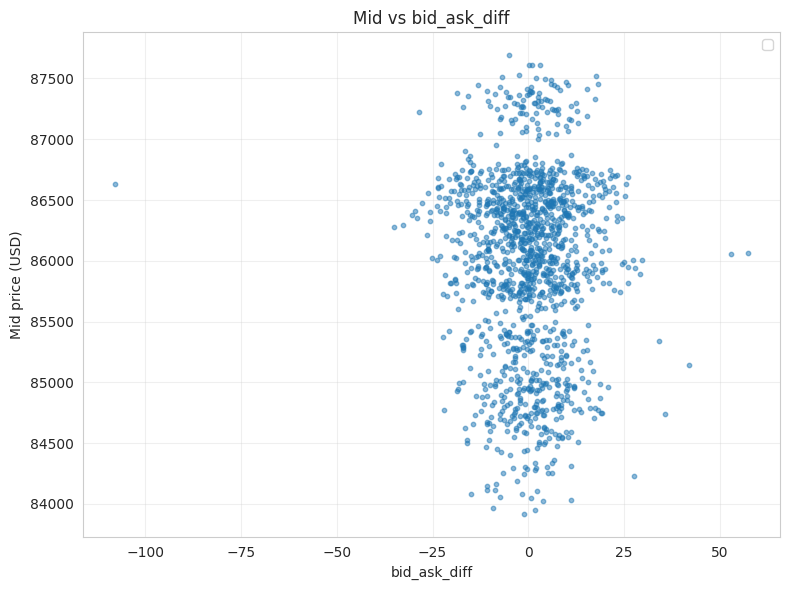

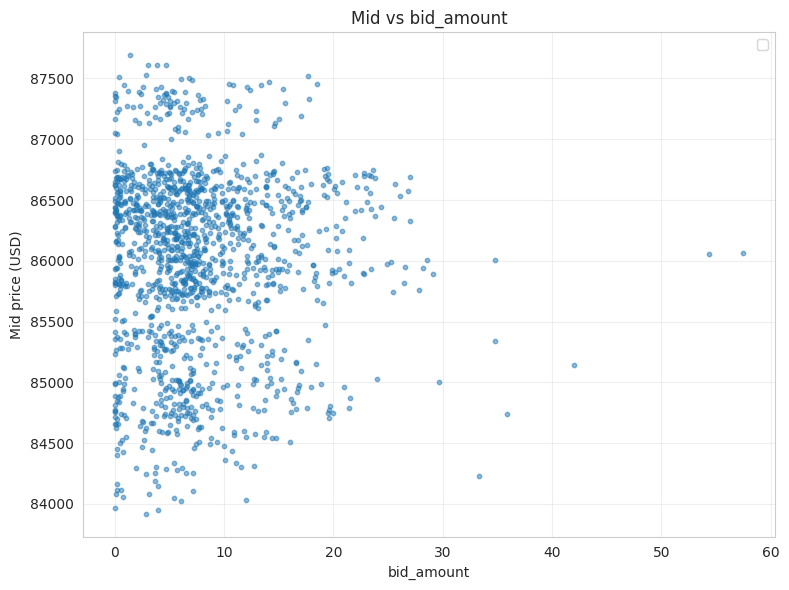

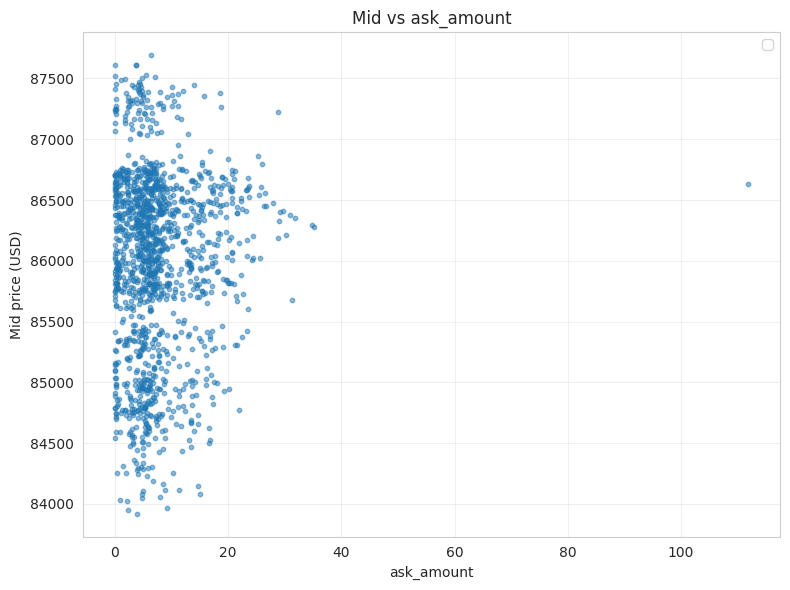

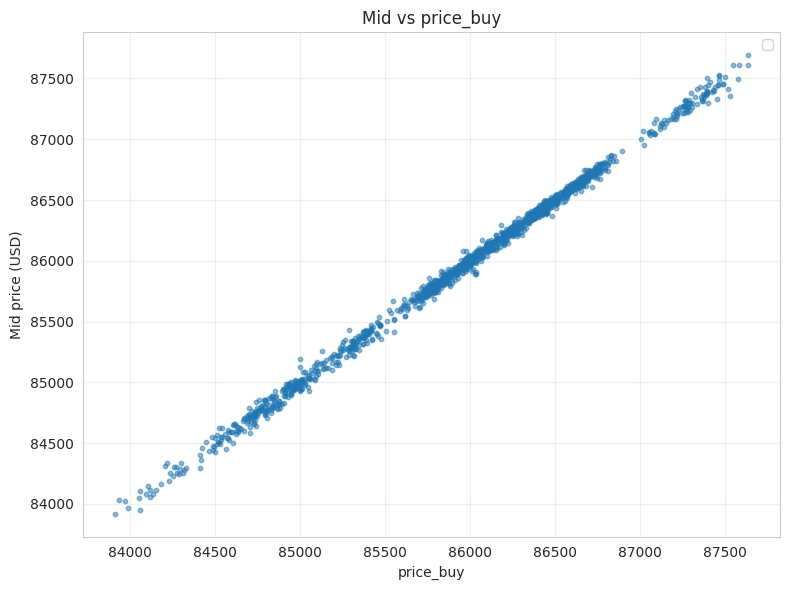

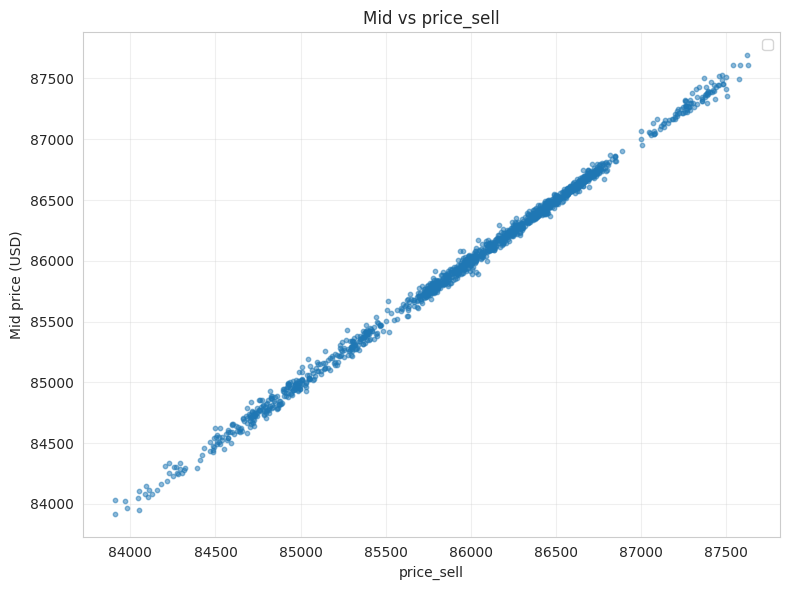

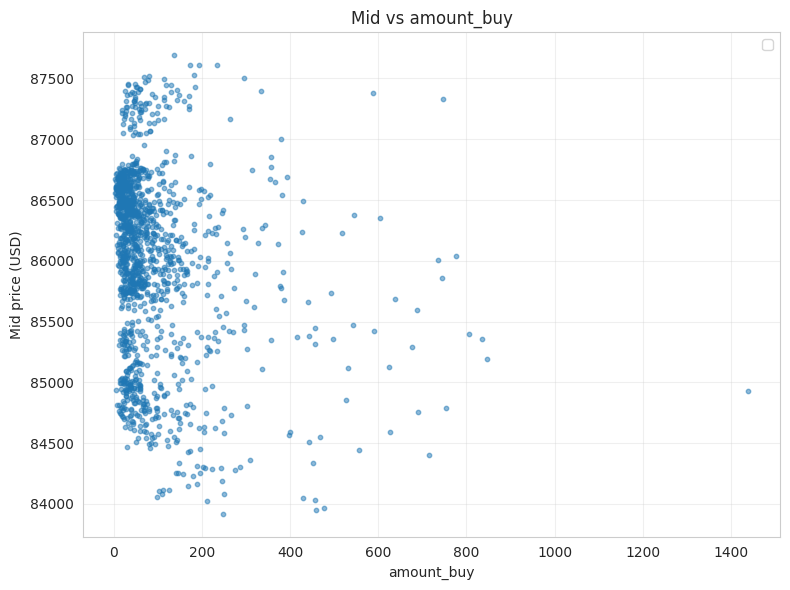

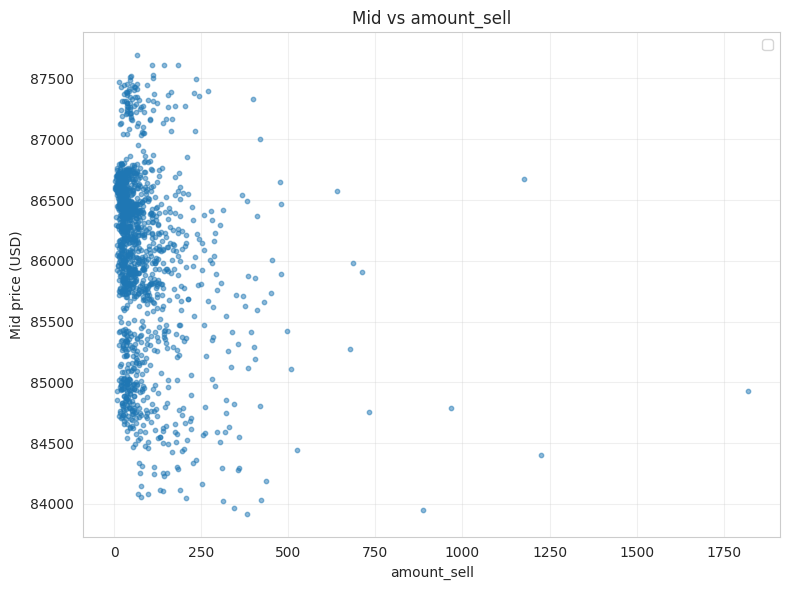

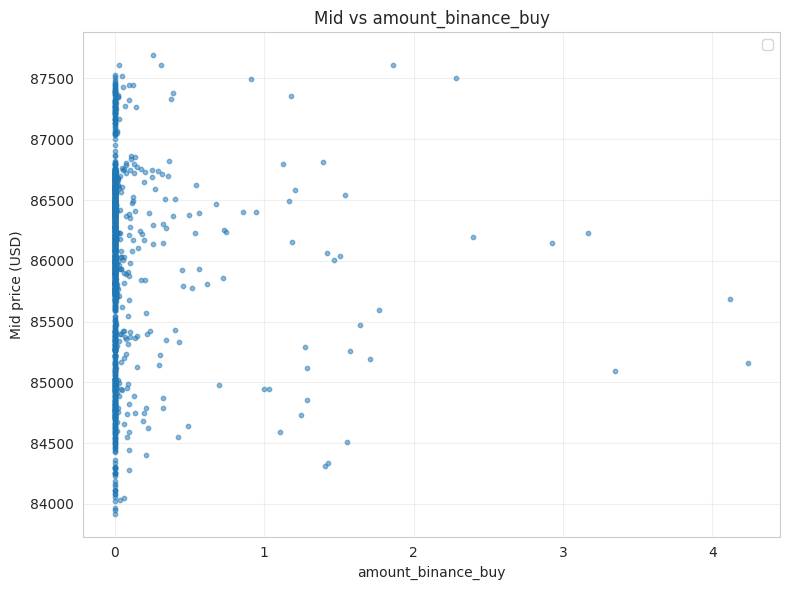

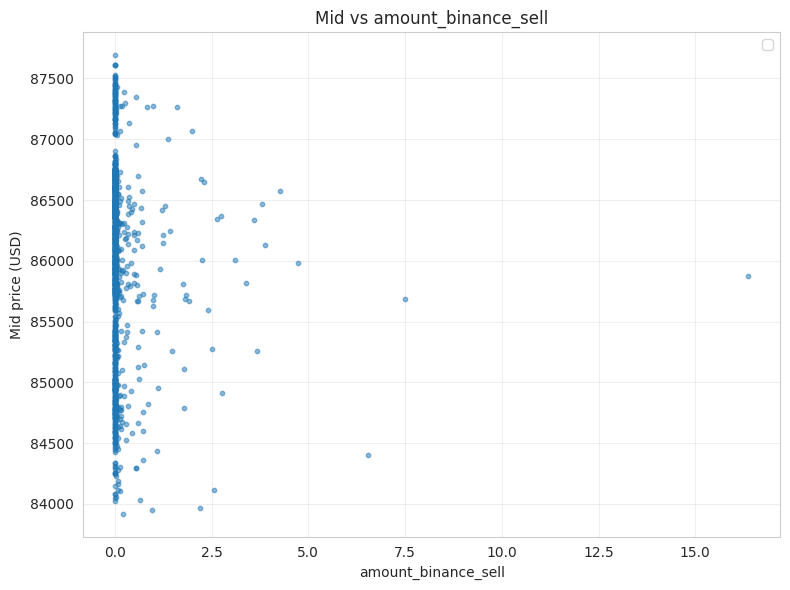

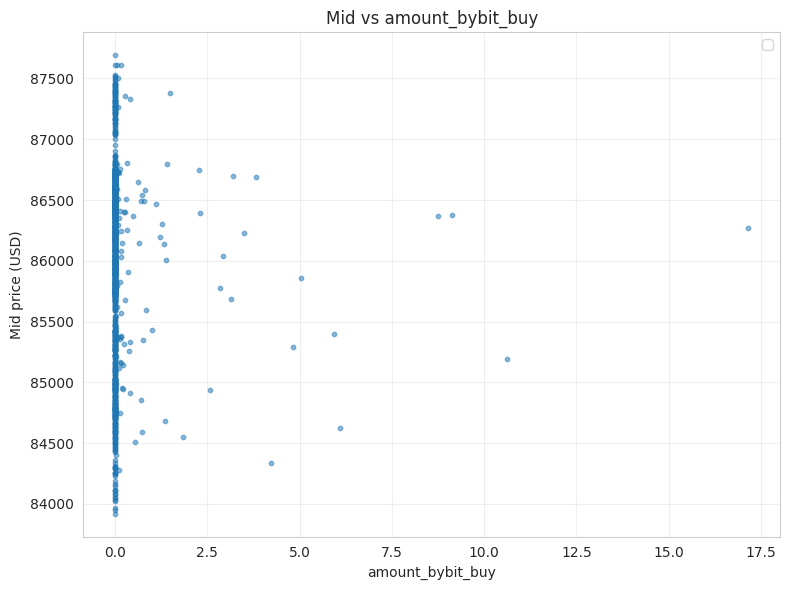

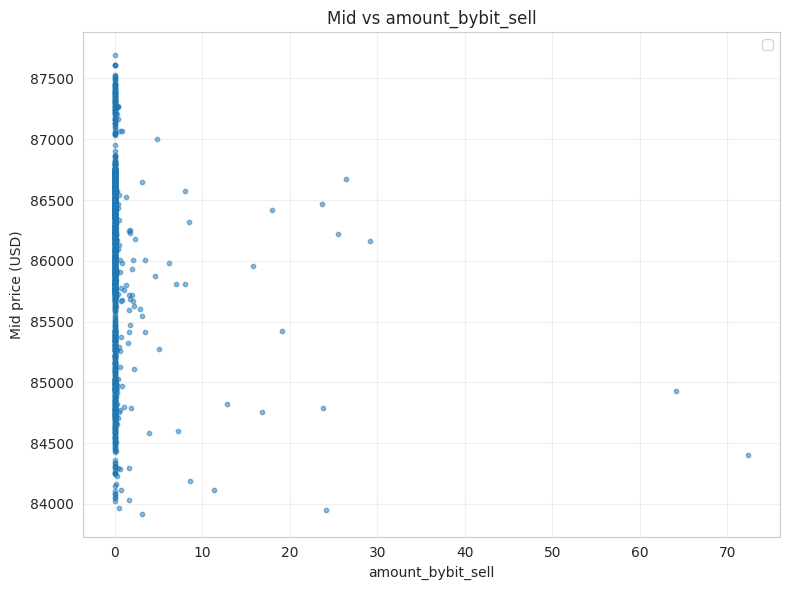

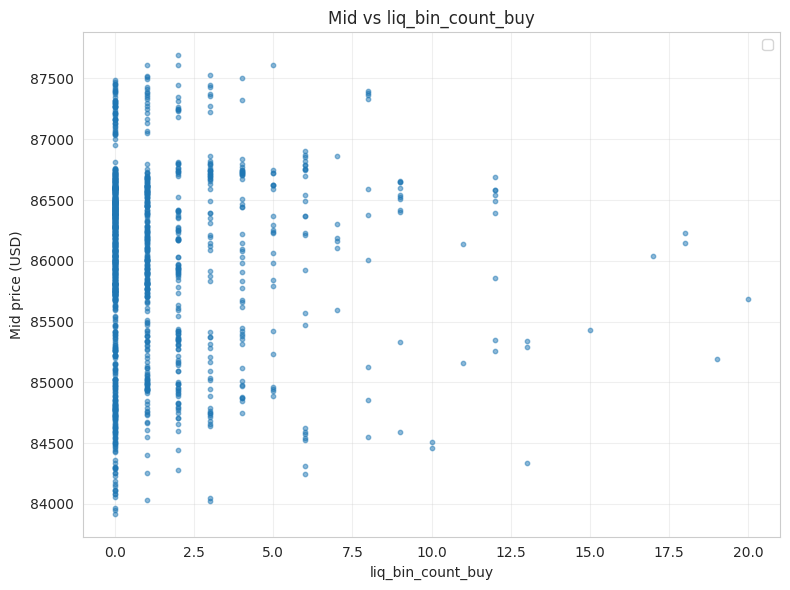

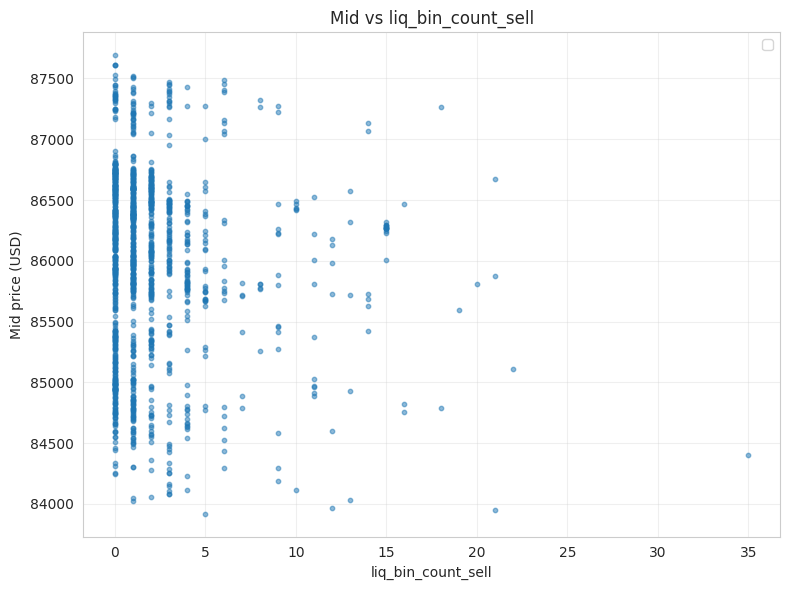

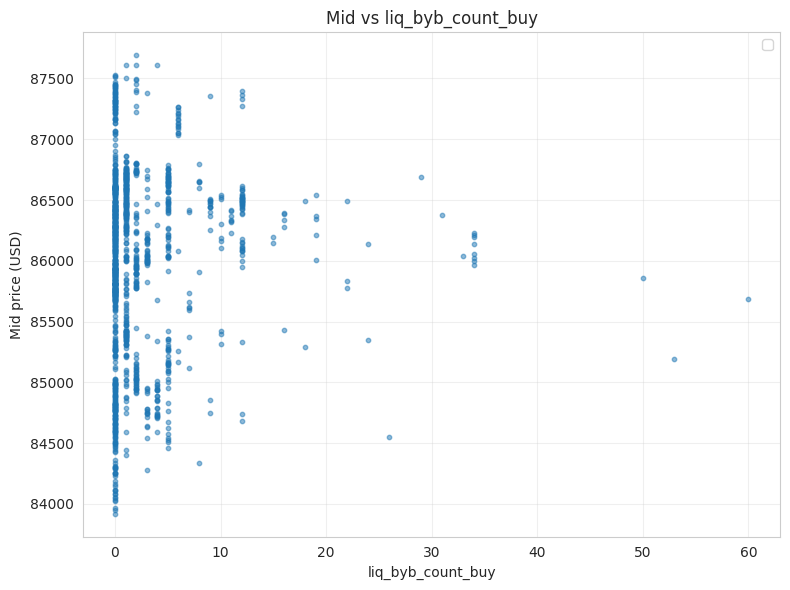

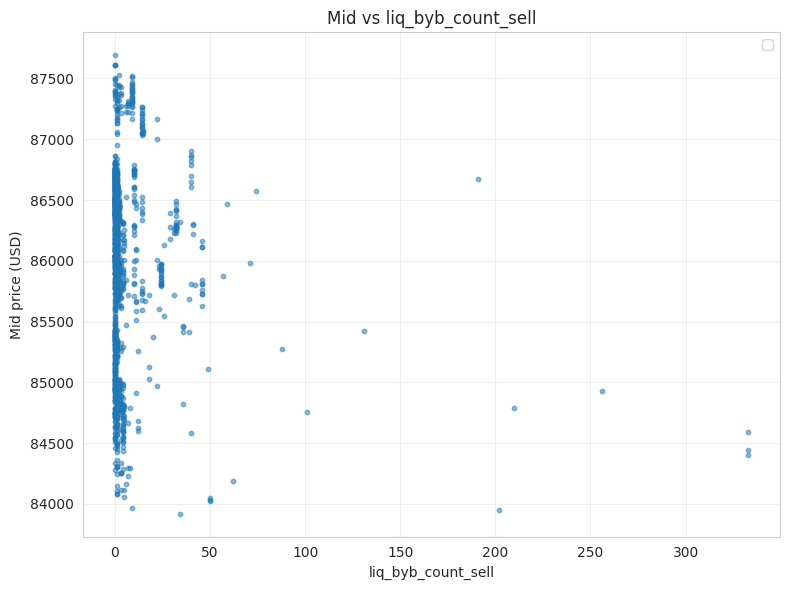

Корреляции с mid price:
mid                    1.000000
price_sell             0.999060
price_buy              0.999042
liq_byb_count_sell     0.133289
liq_bin_count_sell     0.130440
amount_bybit_sell      0.121496
amount_binance_sell    0.107616
amount_sell            0.094782
spread                 0.050058
amount_buy             0.017517
liq_byb_count_buy      0.003921
ask_amount             0.001193
amount_binance_buy    -0.010009
bid_ask_diff          -0.018781
liq_bin_count_buy     -0.019734
bid_amount            -0.029109
amount_bybit_buy      -0.029266
volatility            -0.425827
Name: mid, dtype: float64


In [ ]:
# Для ускорения берём выборку каждые 10 минут
df_sample = df_features.resample('1min').last().dropna()

predictors = [
    'volatility', 'spread', 'bid_ask_diff', 'bid_amount', 'ask_amount',
    'price_buy', 'price_sell', 'amount_buy', 'amount_sell',
    'amount_binance_buy', 'amount_binance_sell',
    'amount_bybit_buy', 'amount_bybit_sell',
    'liq_bin_count_buy', 'liq_bin_count_sell', 'liq_byb_count_buy', 'liq_byb_count_sell'
]

for pred in predictors:
    if pred not in df_sample.columns:
        continue
    if df_sample[pred].isna().all():
        continue
    plt.figure(figsize=(8,6))
    x = df_sample[pred].values
    y = df_sample['mid'].values
    plt.scatter(x, y, alpha=0.5, s=10)
    plt.xlabel(pred)
    plt.ylabel('Mid price (USD)')
    plt.title(f'Mid vs {pred}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Матрица корреляций
corr = df_features[['mid'] + [c for c in predictors if c in df_features.columns]].corr()
print("Корреляции с mid price:")
print(corr['mid'].sort_values(ascending=False))